# Анализ "стабильности" полей

**Дата: 21.08.2026**

----

#### Задача: 
- **Выявить аномалии урожайности на стабильных полях (с историей наблюдений более 3 лет) и оценить влияние факторов севооборота и агрохимии на продуктивность.**

#### Цели: 
- Отфильтровать датасет, сформировав массив стабильных полей с историей наблюдений более 3 лет.

- Найти года с отклонениями урожайности (аномалиями), определить характер аномалий и отклонение.

- Проанализировать воздействие предшествующих культур на урожайность.

- Оценить корреляцию между удобрениями и СЗР (средств защиты растений) и продуктивностью полей.

----

## 1. Подготовка рабочего пространства

### Импорт библиотек

In [1]:
import re
import os
import numpy as np
import pandas as pd
from IPython.display import display
from openpyxl.utils import get_column_letter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
import seaborn as sns
import textwrap

print('Готово')

Готово


### Загрузка и подготовка данных

In [2]:
# Список 
datasets = {
    'df_fields': 'data_input/fields.csv',
}

# Словарь для сохранения
data = {}

for name, path in datasets.items():
    print('-' * 50)
    print(f"Загрузка: {name}")
    
    df = pd.read_csv(path)
    
    print("Размер:", df.shape)
    print("Столбцы:", df.columns.tolist())
    
    data[name] = df

# Сохр. в перменные
df_fields = data['df_fields']


print('-' * 50)
print("\nДатасет загружен")

display(df_fields.head(5))

--------------------------------------------------
Загрузка: df_fields
Размер: (155510, 13)
Столбцы: ['field_id', 'field_name', 'division', 'area_ha', 'year', 'crop_id', 'variety', 'sowing_date', 'harvesting_date', 'productivity', 'expected_yield', 'is_active', 'crop_name']
--------------------------------------------------

Датасет загружен


,field_id,field_name,division,area_ha,year,crop_id,variety,sowing_date,harvesting_date,productivity,expected_yield,is_active,crop_name
0,2142,23-28-КНЛВ-057,Дивизион Север,133.0,2016,66.0,П 9578,2016-04-21,NaN,55.650000,NaN,True,Кукуруза на зерно
1,2142,23-28-КНЛВ-057,Дивизион Север,133.0,2017,52.0,"Амбадор РС1, Баграт ЭС, Курс ЭС, Морозко ЭС, Т...",2016-10-27,NaN,68.011666,NaN,True,Пшеница озимая
2,2142,23-28-КНЛВ-057,Дивизион Север,133.0,2018,30.0,Мадонна РС2,2018-04-08,NaN,27.390000,NaN,True,Горох
3,2142,23-28-КНЛВ-057,Дивизион Север,133.0,2019,52.0,Юбилейная 100 РС1,2018-09-23,NaN,57.770000,NaN,True,Пшеница озимая
4,2142,23-28-КНЛВ-057,Дивизион Север,133.0,2020,60.0,"Неро F-1, Неро F-1",2020-03-21,NaN,284.090000,NaN,True,Свекла сахарная


In [3]:
# ------------------------------------------------------
#размер 
print("Размер датасета:", df_fields.shape)

# ищем пропуски
print('\nПропусков:')
print(df_fields.isnull().sum())

# проверка на дубликаты
print('\nДубликатов:',df_fields.duplicated().sum())

print('\nКол-во значений')
print(df_fields.nunique())

print('\nОбщая информация:')
df_fields.info()

# описание данных
print('\nОписание данных')
df_fields.describe().round(2)

Размер датасета: (155510, 13)

Пропусков:
field_id                0
field_name              0
division                0
area_ha              1160
year                    0
crop_id             54010
variety             72520
sowing_date         73835
harvesting_date    144129
productivity        72088
expected_yield     154428
is_active               0
crop_name           54010
dtype: int64

Дубликатов: 0

Кол-во значений
field_id           15551
field_name         15547
division               8
area_ha             1511
year                  10
crop_id               99
variety             8176
sowing_date         1858
harvesting_date      254
productivity       28011
expected_yield         1
is_active              2
crop_name             99
dtype: int64

Общая информация:
<class 'pandas.DataFrame'>
RangeIndex: 155510 entries, 0 to 155509
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   field_id         15

,field_id,area_ha,year,crop_id,productivity,expected_yield
count,155510.00,154350.00,155510.00,101500.00,83422.00,1082.0
mean,22567.03,71.32,2020.50,51.32,74.20,0.0
std,9290.28,60.04,2.87,20.37,260.11,0.0
min,2142.00,0.03,2016.00,1.00,0.00,0.0
25%,16436.00,29.00,2018.00,52.00,27.42,0.0
50%,21196.00,64.00,2020.50,52.00,48.07,0.0
75%,26039.00,97.00,2023.00,55.00,65.05,0.0
max,61051.00,1535.66,2025.00,171.00,64540.00,0.0


**Ппромежуточный вывод:**
    
- Выброс в productivity (максимум 64 540 ц/га).
    - Предел урожайности большинства культур лежит в диапазоне 10–150 ц/га. Значение 64 540 - это явная ошибка ввода (например, в колонку попал валовый сбор в тоннах или килограммах вместо урожайности). Медиана при этом составляет 48.07 ц/га, а 75%-квантиль - 65.05 ц/га, что отражает нормальные распределение.

- Бесполезный признак expected_yield.
    - Из 155 510 строк заполнено всего 1 082 (99.3% пропусков), при этом все известные значения равны 0.0. Эту колонку можно сразу удалять.

- Пропуски в культурах и урожайности (crop_name и productivity)
    - В 54 010 строках (34.7%) отсутствует культура (crop_id / crop_name), а в 72 088 строках (46.4%) нет урожайности. Это ситуация, когда земля "отдыхает" или период, когда поле еще не было введено в оборот. Эти пропуски нужно будет разметить.

- Пропуски в площади area_ha (1 160 строк).


- Преобладание одной культуры.
    - crop_id = 52.0 попадает на квантили 25%, 50% и 75%. Это указывает на доминирующий вид посевов.

---

### Обработка

In [4]:
# очистка
df_clean = df_fields.copy()
df_clean["crop_name"] = (
    df_clean["crop_name"].fillna("Пар").astype(str).str.strip()
)
df_clean["division"] = df_clean["division"].astype(str).str.strip()
df_clean["year"] = pd.to_numeric(df_clean["year"], errors="coerce")

# Маркировка Пара (строка остаётся, продуктивность обнуляется)
is_fallow = df_clean["crop_name"].str.contains(
    "Пар|Не засеяно", case=False, na=False
)
df_clean.loc[is_fallow, "productivity"] = np.nan

# Фильтрация 1% верхних выбросов по 99-му квантилю
q99 = df_clean.groupby(["crop_name", "year"])["productivity"].transform(
    lambda x: x.quantile(0.99)
)
df_clean.loc[df_clean["productivity"] > q99, "productivity"] = np.nan

# Расчет относительного индекса продуктивности (yield_ratio)
div_median = df_clean.groupby(["crop_name", "division", "year"])[
    "productivity"
].transform("median")
df_clean["yield_ratio"] = df_clean["productivity"] / div_median

# сортировка и расчет предшественников
df_clean = df_clean.sort_values(by=["field_id", "year"]).reset_index(drop=True)
df_clean["prev_crop"] = df_clean.groupby("field_id")["crop_name"].shift(1)
df_clean["prev_year"] = df_clean.groupby("field_id")["year"].shift(1)

is_consecutive = (df_clean["year"] - df_clean["prev_year"]) == 1
df_clean.loc[~is_consecutive, "prev_crop"] = np.nan

# Расчет стабильности поля по всем доступным yield_ratio
df_clean["stability"] = (
    df_clean.groupby("field_id")["yield_ratio"].transform("std").fillna(0)
)

# ----------------
print(f"Дубликатов по ключу [field_id, year] до очистки: {df_clean.duplicated(subset=['field_id', 'year']).sum()}")


# Удаляем дубликаты, оставляя первую найденную запись. 
df_clean = df_clean.drop_duplicates(subset=['field_id', 'year'], keep='first').reset_index(drop=True)

print(f"Дубликатов по ключу [field_id, year] после очистки: {df_clean.duplicated(subset=['field_id', 'year']).sum()}")
print(f"Итоговый размер df_clean: {len(df_clean)} строк (было 155510)")

# ----------------

# Удаление служебного столбца
df_clean = df_clean.drop(columns=["prev_year"])

# Сохранение
output_dir = "df_clean_stability"
os.makedirs(output_dir, exist_ok=True)

# Сохранение CSV
csv_path = os.path.join(output_dir, "clean_data_stability.csv")
df_clean.to_csv(csv_path, index=False, encoding="utf-8-sig")

# Сохранение Excel с автонастройкой ширины колонок
xlsx_path = os.path.join(output_dir, "clean_data_stability.xlsx")
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    df_clean.to_excel(writer, sheet_name="Очищенные данные", index=False)
    worksheet = writer.sheets["Очищенные данные"]

    for col_idx, col_name in enumerate(df_clean.columns, 1):
        col_letter = get_column_letter(col_idx)
        max_len = df_clean[col_name].astype(str).str.len().max()
        max_len = max(max_len, len(col_name))
        worksheet.column_dimensions[col_letter].width = min(max_len + 2, 50)

print(f"Данные успешно обработаны и сохранены в папку '{output_dir}'")
print(f"Всего строк в итоговом датасете (включая пар): {len(df_clean)}")
print(f"Уникальных полей: {df_clean['field_id'].nunique()}")

Дубликатов по ключу [field_id, year] до очистки: 0
Дубликатов по ключу [field_id, year] после очистки: 0
Итоговый размер df_clean: 155510 строк (было 155510)
Данные успешно обработаны и сохранены в папку 'df_clean_stability'
Всего строк в итоговом датасете (включая пар): 155510
Уникальных полей: 15551


**Промежуточный вывод:**
    
- Убраны лишние пробелы, годы приведены к числовому формату, а незаполненные названия культур помечены как "Пар".

- Для полей со статусом "Пар" и "Не засеяно" значение урожайности сбрасывается, сохраняя сами записи в истории поля.

- Для каждой пары [Культура + Год] отсечен 1% верхних аномалий и опечаток ввода по 99-му квантилю.

- Рассчитан относительный индекс продуктивности: $$\text{yield_ratio} = \frac{\text{productivity}}{\text{div_median}}$$где $\text{div_median}$ - локальная медиана группы [Культура + Дивизион + Год]. Это избавило от влияния погодных условий конкретного сезона, разницы в биологической урожайности культур и климатических особенностей дивизионов.



- Севооборот (prev_crop): определяется культура-предшественник с проверкой непрерывности лет. Если между записями поля есть пропуск (year - prev_year > 1), предшественник сбрасывается.

- Стабильность (stability): вычисляется стандартное отклонение индекса yield_ratio по каждому полю за все годы.



-----

## 2. Подготовка данных 

---

### Описание 

#### 1. Формула расчета

##### 1.1. Базовая норма поля ($\text{median_yr}$)

Для определения естественного потенциала поля используется медиана индекса урожайности (yield_ratio) за весь период его использования:

$$
\text{median_yr} = \text{Median}(\text{yield_ratio}_1, \text{yield_ratio}_2, \dots, \text{yield_ratio}_n)
$$

**Как читается:** Медиана берется вместо среднего арифметического, чтобы разовые аномальные провалы или рекордные урожаи не искажали представление о нормальной продуктивности поля.

##### 1.2. Относительное отклонение ($\text{dev_pct}$)

Показывает процентное смещение результата конкретного года от медианной нормы поля:

$$
\text{dev_pct} = \left( \frac{\text{yield_ratio} - \text{median_yr}}{\text{median_yr}} \right) \times 100\%
$$

**Как читается:** На сколько процентов фактический индекс урожайности в текущем году отклонился от типичного уровня этого поля.

* Положительное значение - урожай выше нормы.
* Отрицательное значение - урожай ниже нормы.

##### 1.3. Пороговая классификация ($\text{anomaly_type}$)

Аномалией считается событие, выходящее за рамки в $\pm 25\%$:

$$
\text{anomaly_type} = 
\begin{cases} 
\text{"Провал (-)"}, & \text{если } \text{dev_pct} \le -25.0\% \\
\text{"Всплеск (+)"}, & \text{если } \text{dev_pct} \ge +25.0\% \\
\text{"Норма"}, & \text{если } -25.0\% < \text{dev_pct} < +25.0\% 
\end{cases}
$$

---

#### 2. Структура  Excel (`field_anomalies.xlsx`)

* `field_id` / `field_name` - идентификатор и наименование поля.
* `division` - подразделение/филиал.
* `year` / `crop_name` - год и высеваемая культура.
* `prev_crop` - культура предшественник.
* `productivity` - фактическая урожайность (ц/га).
* `yield_ratio` - фактический индекс урожайности.
* `median_yr` - норма поля (медианный индекс).
* `dev_pct` - процент отклонения от нормы.
* `anomaly_type` - характер аномалии (Провал (-) или Всплеск (+)).


----

### Работа с данными

In [5]:
# 1. Настройка путей и загрузка данных
OUTPUT_DIR = "field_stability"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_excel = pd.read_excel("data_output/fields_clustered_all.xlsx")
df_clean = pd.read_csv("df_clean_stability/clean_data_stability.csv")

# Приведение типов
df_clean["field_id"] = df_clean["field_id"].astype(str).str.strip()
df_excel["ID поля"] = df_excel["ID поля"].astype(str).str.strip()

# 2. Фильтрация только стабильных полей (история >= 3 лет)
stable_fields = df_excel[
    (df_excel["Категория стабильности"] == "Стабильное")
    & (df_excel["Лет в обороте"] >= 3)
].copy()

df_merged = df_clean[
    df_clean["field_id"].isin(stable_fields["ID поля"])
].copy()

# 3. Расчет медиан и отклонений
field_stats = (
    df_merged.groupby("field_id")["yield_ratio"]
    .agg(median_yr="median", std_yr="std")
    .reset_index()
)

df_merged = df_merged.merge(field_stats, on="field_id", how="left")

df_merged["diff_yield_ratio"] = df_merged["yield_ratio"] - df_merged["median_yr"]
df_merged["dev_pct"] = (df_merged["diff_yield_ratio"] / df_merged["median_yr"]) * 100

# 4. Детекция аномалий
THRESHOLD = 25.0

is_par = df_merged["crop_name"].str.contains("Пар|Не засеяно", case=False, na=False)
is_missing = df_merged["productivity"].isna() & ~is_par

conditions = [
    is_par,                             # Земля отдыхала
    is_missing,                         # Данные отсутствуют
    df_merged["dev_pct"] <= -THRESHOLD,  # Провал
    df_merged["dev_pct"] >= THRESHOLD,   # Всплеск
]

choices = ["Отдых (Пар)", "Нет данных", "Провал (-)", "Всплеск (+)"]

df_merged["anomaly_type"] = np.select(conditions, choices, default="Норма")
df_merged["is_anomaly"] = df_merged["anomaly_type"].isin(["Провал (-)", "Всплеск (+)"])

# 5. Формирование детального реестра аномалий
anomalies_df = df_merged[df_merged["is_anomaly"]].copy()
anomalies_df["abs_dev_pct"] = anomalies_df["dev_pct"].abs()
anomalies_df = anomalies_df.sort_values(by="abs_dev_pct", ascending=False)

output_cols = [
    "field_id",
    "field_name",
    "division",
    "year",
    "crop_name",
    "prev_crop",
    "productivity",
    "yield_ratio",
    "median_yr",
    "dev_pct",
    "anomaly_type",
]

result_details = anomalies_df[output_cols].copy()
result_details["dev_pct"] = result_details["dev_pct"].round(1)
result_details["yield_ratio"] = result_details["yield_ratio"].round(2)
result_details["median_yr"] = result_details["median_yr"].round(2)
result_details["productivity"] = result_details["productivity"].round(1)

# 6. Сохранение результатов (одна вкладка)
csv_path = os.path.join(OUTPUT_DIR, "field_anomaly_.csv")
excel_path = os.path.join(OUTPUT_DIR, "field_anomalies.xlsx")

result_details.to_csv(csv_path, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    result_details.to_excel(
        writer, sheet_name="Детальные_аномалии", index=False
    )

    # Автонастройка ширины колонок для единственного листа
    worksheet = writer.sheets["Детальные_аномалии"]
    for col in worksheet.columns:
        max_len = max(len(str(cell.value or "")) for cell in col)
        col_letter = get_column_letter(col[0].column)
        worksheet.column_dimensions[col_letter].width = max(max_len + 3, 12)

print(f"Файлы сохранены в '{os.path.abspath(OUTPUT_DIR)}':")
print(f"CSV: {csv_path}")
print(f"Excel: {excel_path}")

Файлы сохранены в 'C:\Users\Admin\fields_clusters_final\field_stability':
CSV: field_stability\field_anomaly_.csv
Excel: field_stability\field_anomalies.xlsx


### Карточка поля

In [6]:
# Поля, у которых есть аномалии (для проверки "взлетов" и "провалов")
ids_with_anomalies = (
    df_merged[df_merged["is_anomaly"]]["field_id"].unique()[:5].tolist()
)
print("Примеры ID полей с аномалиями:", ids_with_anomalies)

# Поля, которые работали стабильно (без аномалий)
ids_perfect = (
    set(df_merged["field_id"].unique())
    - set(df_merged[df_merged["is_anomaly"]]["field_id"].unique())
)
print("Примеры ID полей без аномалий:", list(ids_perfect)[:5])

Примеры ID полей с аномалиями: ['6294', '7045', '7131', '7140', '12360']
Примеры ID полей без аномалий: ['17805', '17486', '25362', '17519', '13179']


In [55]:
def show_field_card(field_id):
    """Выводит полную историю поля со статусом лет"""
    field_id_str = str(field_id).strip()

    field_data = df_merged[
        df_merged["field_id"].astype(str) == field_id_str
    ].copy()

    if field_data.empty:
        print(f"Поле с id {field_id} не найдено.")
        return

    info = field_data.iloc[0]
    excel_meta_df = df_excel[df_excel["ID поля"].astype(str) == field_id_str]

    if excel_meta_df.empty:
        print(f"Данные для поля с id {field_id} не найдены в excel.")
        return

    excel_meta = excel_meta_df.iloc[0]

    print(f"Карточка поля: {info['field_name']} (id: {field_id})")
    print(
        f"Дивизион: {info['division']} | Площадь: {excel_meta.get('Площадь поля (га)', 'н/д')} га"
    )
    print(
        f"Статус в excel: {excel_meta.get('Категория урожайности (Правила)', 'н/д')} | {excel_meta.get('Категория стабильности', 'н/д')}"
    )
    print(
        f"Медианный индекс урожайности: {info['median_yr']:.3f} | Разброс (std): {info['std_yr']:.3f}"
    )
    print("-" * 50)

    cols = [
        "year",
        "crop_name",
        "productivity",
        "yield_ratio",
        "dev_pct",
        "anomaly_type",
    ]
    history = field_data[cols].copy()

    # Статусы
    status_map = {
        "Отдых (Пар)": "отдых",
        "Нет данных": "нет данных",
        "Норма": "норма",
        "Провал (-)": "аномалия",
        "Всплеск (+)": "аномалия",
    }
    history["Статус"] = history["anomaly_type"].map(status_map)

    history.columns = [
        "Год",
        "Культура",
        "Урожайность (ц/га)",
        "Индекс урожайности",
        "Отклонение (%)",
        "Тип отклонения",
        "Статус",
    ]

    history["Урожайность (ц/га)"] = history["Урожайность (ц/га)"].round(1)
    history["Индекс урожайности"] = history["Индекс урожайности"].round(3)
    history["Отклонение (%)"] = history["Отклонение (%)"].round(1)

    display(history)

    anomalies = field_data[field_data["is_anomaly"]]
    if len(anomalies) > 0:
        print(
            f"\nОбнаружено аномалий: {len(anomalies)} год(а) из {len(history)}."
        )
        for _, row in anomalies.iterrows():
            direction = "взлет" if row["dev_pct"] > 0 else "провал"
            print(
                f"   - {int(row['year'])} ({row['crop_name']}): {direction} ({row['dev_pct']:+.1f}%)"
            )
    else:
        print("\nАномалий не обнаружено.")
    print("\n")

# Пример вызова 
show_field_card(12360)

Карточка поля: 26-03-ДИВН-127 (id: 12360)
Дивизион: Дивизион Новокубанский | Площадь: 78.0 га
Статус в excel: Среднее | Стабильное
Медианный индекс урожайности: 1.031 | Разброс (std): 0.181
--------------------------------------------------


,Год,Культура,Урожайность (ц/га),Индекс урожайности,Отклонение (%),Тип отклонения,Статус
70,2016,Пшеница озимая,66.0,1.421,37.8,Всплеск (+),аномалия
71,2017,Пшеница озимая,49.8,0.927,-10.0,Норма,норма
72,2018,Пар,NaN,NaN,NaN,Отдых (Пар),отдых
73,2019,Пшеница озимая,50.6,0.945,-8.4,Норма,норма
74,2020,Пар,NaN,NaN,NaN,Отдых (Пар),отдых
75,2021,Пшеница озимая,54.0,1.059,2.7,Норма,норма
76,2022,Пар,NaN,NaN,NaN,Отдых (Пар),отдых
77,2023,Пшеница озимая,49.9,1.051,2.0,Норма,норма
78,2024,Пар,NaN,NaN,NaN,Отдых (Пар),отдых
79,2025,Пшеница озимая,64.7,1.011,-2.0,Норма,норма



Обнаружено аномалий: 1 год(а) из 10.
   - 2016 (Пшеница озимая): взлет (+37.8%)




### Обьяснение

Если пошагово то так:

#### 1. Индекс года ($\text{yield_ratio}$)
Урожайность поля делится на медиану дивизиона по той же культуре и за тот же год.

* **2016 год:** $66.0 / 46.44 = \mathbf{1.421}$ (поле сработало на $+42.1\%$ лучше "нормы").
* **2025 год:** $64.7 / 64.0 = \mathbf{1.011}$ (поле сработало на уровне "нормы").

#### 2. Норма поля ($\text{median_yr}$)
Рассчитывается как медиана всех $\text{yield_ratio}$ поля за его активные годы (тут **1.031**).

#### 3. Отклонение ($\text{dev_pct}$)
Сравнивает результат конкретного года с нормой поля:

$$
\text{dev_pct} = \left( \frac{\text{yield_ratio} - \text{median_yr}}{\text{median_yr}} \right) \times 100\%
$$

* **2016 год:**  
  $$
  \frac{1.421 - 1.031}{1.031} \times 100\% = \mathbf{+37.8\%}
  $$  
  Значение выше порога $+25\%$, поэтому пишется **«Всплеск (+)»** (аномалия).

* **2025 год:**  
  $$
  \frac{1.011 - 1.031}{1.031} \times 100\% = \mathbf{-2.0\%}
  $$  
  Значение находится внутри интервала $\pm 25\%$, поэтомуэ это **«Норма»**.


#### И что в итоге:

* **В 2016 году** поле "выделилось" на фоне района и сработало **аномально лучше** своей нормы.
* **В 2025 году** при тех же абсолютных цифрах урожайность была высокой у всего района, поэтому поле отработало в рамках своей **нормальной эффективности**.

---

## Исследование данных

### Динамика урожайности по культурам и дивизионам

#### Кол-во культур

In [8]:
pd.set_option("display.max_rows", None)

print("Культуры")
print(df_merged["crop_name"].value_counts(dropna=False))

Культуры
crop_name
Пшеница озимая                                        15526
Пар                                                    5495
Подсолнечник масличный                                 3272
Свекла сахарная                                        2413
Соя                                                    2220
Кукуруза на зерно                                      2115
Ячмень озимый                                          1487
Рис                                                    1370
Многолетние травы прошлых лет                          1282
Кукуруза на силос и зеленый корм                       1223
Горох                                                   764
АМП                                                     611
Пшеница яровая мягкая                                   474
Подсолнечник СПК (крупноплодный)                        461
Многолетние травы текущего года                         430
Рапс озимый                                             304
Лен масличный        

#### Код визуализаций

In [9]:
CHARTS_DIR = "dynamics"
os.makedirs(CHARTS_DIR, exist_ok=True)
# Список целевых культур
target_crops = [
    "Пшеница озимая",
    "Подсолнечник масличный",
    "Пшеница яровая мягкая",
    "Кукуруза на зерно",
]

# убираем Пар, NaN и оставляем только целевые культуры
df_active = df_merged[
    df_merged["productivity"].notna()
    & ~df_merged["crop_name"].str.contains("Пар", na=False)
    & df_merged["crop_name"].isin(target_crops)
].copy()

# приводим год к целочисленному типу
df_active["year"] = df_active["year"].astype(int)

# агрегация медианы урожайности
macro_trends = (
    df_active.groupby(["division", "crop_name", "year"])["productivity"]
    .median()
    .reset_index()
)

# Генерация графиков
chart_count = 0

for division in macro_trends["division"].unique():
    div_data = macro_trends[macro_trends["division"] == division]

    for crop in div_data["crop_name"].unique():
        subset = div_data[div_data["crop_name"] == crop].sort_values("year")

        # Строим график только если есть хотя бы 3 года истории
        if len(subset) < 3:
            continue

        fig, ax = plt.subplots(figsize=(10, 4.5))
        ax.plot(
            subset["year"],
            subset["productivity"],
            marker="o",
            color="#1f77b4",
            linewidth=2.5,
        )

        ax.set_title(
            f"Динамика: '{crop}'\n{division}",
            fontsize=11,
            fontweight="bold",
        )
        ax.set_xlabel("Год")
        ax.set_ylabel("Медиана урожайности (ц/га)")
        ax.grid(True, linestyle="--", alpha=0.5)

        # Ограничение оси X только целыми годами без дробей
        ax.set_xticks(subset["year"].unique())
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%d"))

        # Вывод чисел над точками
        for _, row in subset.iterrows():
            ax.annotate(
                f"{row['productivity']:.1f}",
                (row["year"], row["productivity"]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontweight="bold",
            )

        safe_div = re.sub(r'[\\/*?:"<>|]', "", str(division)).replace(" ", "_")
        safe_crop = re.sub(r'[\\/*?:"<>|]', "", str(crop)).replace(" ", "_")
        filename = f"{safe_div}__{safe_crop}.png"

        plt.tight_layout()
        plt.savefig(os.path.join(CHARTS_DIR, filename), dpi=150)
        plt.close(fig)
        chart_count += 1

print(f"Генерация завершена. Сформировано графиков: {chart_count}")

Генерация завершена. Сформировано графиков: 19


---
#### Пример

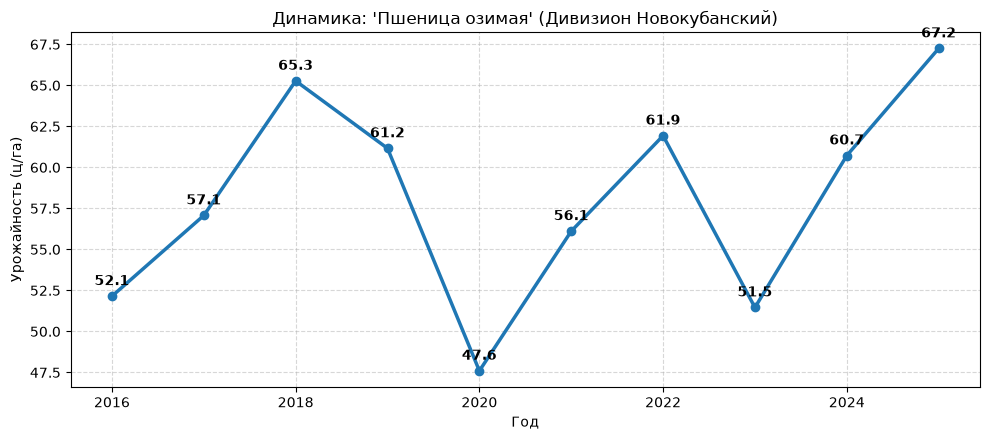

In [10]:
target_division = "Дивизион Новокубанский"
target_crop = "Пшеница озимая"

# Фильтрация дивизиону и культуре
regional_trend = (
    df_merged[
        (df_merged["division"] == target_division)
        & (df_merged["crop_name"] == target_crop)
    ]
    .groupby("year")["productivity"]
    .median()
    .reset_index()
)

# Отрисовка
plt.figure(figsize=(10, 4.5))
plt.plot(
    regional_trend["year"],
    regional_trend["productivity"],
    marker="o",
    color="#1f77b4",
    linewidth=2.5,
)

plt.title(
    f"Динамика: '{target_crop}' ({target_division})", fontsize=12
)
plt.xlabel("Год")
plt.ylabel("Урожайность (ц/га)")
plt.grid(True, linestyle="--", alpha=0.5)

for _, row in regional_trend.iterrows():
    plt.annotate(
        f"{row['productivity']:.1f}",
        (row["year"], row["productivity"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

**Промежуточный вывод**

- Из датасета df_merged (стабильные поля, больше 3-х лет истории) отфильтрованы 4 целевые культуры (без паров и пропущенных значений) и для каждой комбинации "дивизион - культура" рассчитана ежегодная медианная урожайность (ц/га). Сформировано и сохранено 19 отдельных файлов с графиками динамики.


- На графиках изображен многолетний тренд медианной урожайности конкретной культуры в рамках одного дивизиона (как в примере).


---

### Одна культура и все дивизионы

In [11]:
# Список культур
target_crops = [
    "Пшеница озимая",
    "Подсолнечник масличный",
    "Пшеница яровая мягкая",
    "Кукуруза на зерно",
]

# 1 культура, все дивизионы
output_dir_crops = "dynamics_crop"
os.makedirs(output_dir_crops, exist_ok=True)

print("Генерация графиков - по культурам")
for crop in target_crops:
    df_crop = df_merged[df_merged["crop_name"] == crop]

    if df_crop.empty:
        print(f"Предупреждение: Данные по культуре '{crop}' не найдены.")
        continue

    # годы по строкам, дивизионы по колонкам
    pivot_crop = (
        df_crop.groupby(["year", "division"])["productivity"]
        .median()
        .unstack()
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    pivot_crop.plot(kind="line", marker="o", linewidth=2, ax=ax)

    ax.set_title(
        f"Динамика урожайности: {crop} (по дивизионам)", fontweight="bold"
    )
    ax.set_ylabel("Урожайность, ц/га")
    ax.set_xlabel("Год")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(title="Дивизион", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()

    # Сохранение 
    safe_filename = crop.replace(" ", "_")
    filepath = os.path.join(output_dir_crops, f"crop_{safe_filename}.png")
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close(fig) 

    print(f"Сохранен: {filepath}")

Генерация графиков - по культурам
Сохранен: dynamics_crop\crop_Пшеница_озимая.png
Сохранен: dynamics_crop\crop_Подсолнечник_масличный.png
Сохранен: dynamics_crop\crop_Пшеница_яровая_мягкая.png
Сохранен: dynamics_crop\crop_Кукуруза_на_зерно.png


#### Пример

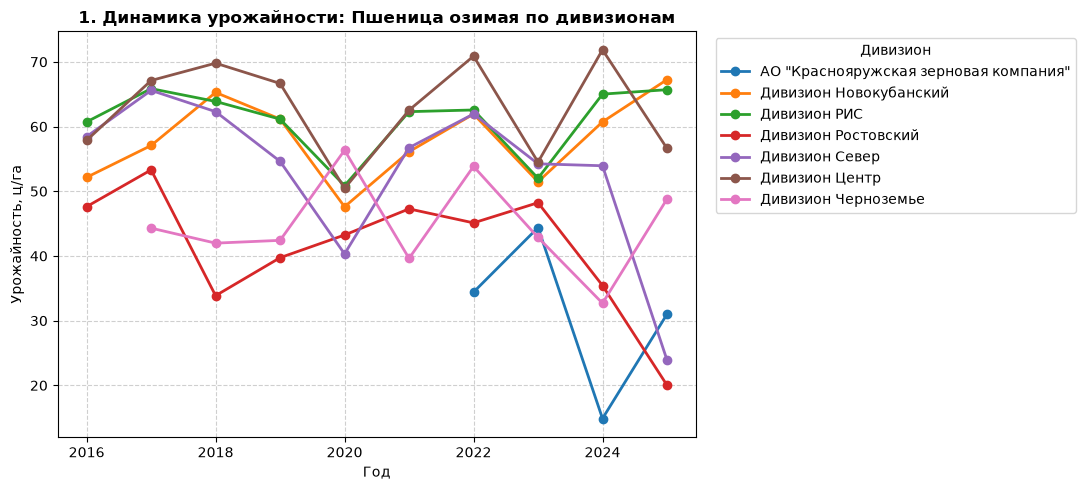

In [12]:
target_crop = "Пшеница озимая"

pivot_crop = (
    df_merged[df_merged["crop_name"] == target_crop]
    .groupby(["year", "division"])["productivity"]
    .median()
    .unstack()
)

fig, ax1 = plt.subplots(figsize=(11, 5))
pivot_crop.plot(kind="line", marker="o", linewidth=2, ax=ax1)

ax1.set_title(
    f"1. Динамика урожайности: {target_crop} по дивизионам", fontweight="bold"
)
ax1.set_ylabel("Урожайность, ц/га")
ax1.set_xlabel("Год")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend(title="Дивизион", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Промежуточный вывод**

- Для целевой группы культур построена таблица с расчетом медианной урожайности по годам со всеми доступными дивизионами. Сформировано и сохранено 4 графика в папку dynamics_crop.

- На графиках изображена динамика медианной урожайности выбранной культуры (в примере это озимой пшеница) одновременно по всем дивизионам, это позволяет сопоставить их продуктивность и региональные тренды по годам.


---

### Один дивизион и все культуры

In [13]:
output_dir_divs = "dynamics_division"
os.makedirs(output_dir_divs, exist_ok=True)

# Получаем список всех уникальных дивизионов из датасета
all_divisions = df_merged["division"].dropna().unique()

print("\nГенерация графиков - по дивизионам")
for division in all_divisions:
    # Фильтруем текущий дивизион и выбранные культуры
    df_div = df_merged[
        (df_merged["division"] == division)
        & (df_merged["crop_name"].isin(target_crops))
    ]

    if df_div.empty:
        continue

    # годы по строкам, культуры по колонкам
    pivot_div = (
        df_div.groupby(["year", "crop_name"])["productivity"]
        .median()
        .unstack()
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    pivot_div.plot(kind="line", marker="s", linewidth=2, ax=ax)

    ax.set_title(
        f"Динамика урожайности: {division} (целевые культуры)",
        fontweight="bold",
    )
    ax.set_ylabel("Урожайность, ц/га")
    ax.set_xlabel("Год")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(title="Культура", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()

    # Сохранение файла
    safe_div_name = (
        str(division)
        .replace(" ", "_")
        .replace("/", "_")
        .replace('"', "")
    )
    filepath = os.path.join(output_dir_divs, f"division_{safe_div_name}.png")
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Сохранен: {filepath}")


Генерация графиков - по дивизионам
Сохранен: dynamics_division\division_Дивизион_Новокубанский.png
Сохранен: dynamics_division\division_Дивизион_Центр.png
Сохранен: dynamics_division\division_Дивизион_Север.png
Сохранен: dynamics_division\division_Дивизион_РИС.png
Сохранен: dynamics_division\division_Дивизион_Ростовский.png
Сохранен: dynamics_division\division_Дивизион_Черноземье.png
Сохранен: dynamics_division\division_АО_Краснояружская_зерновая_компания.png


#### Пример

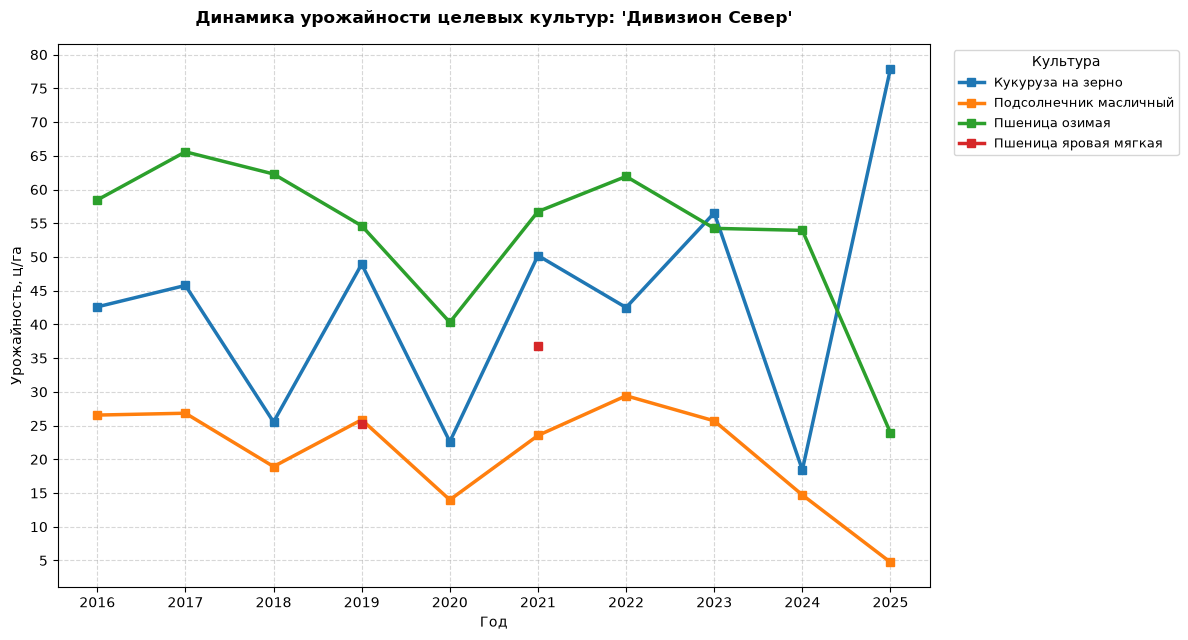

In [14]:
target_division = "Дивизион Север"

# Список целевых культур
target_crops = [
    "Пшеница озимая",
    "Подсолнечник масличный",
    "Пшеница яровая мягкая",
    "Кукуруза на зерно",
]

# Фильтр по дивизиону, целевым культурам и наличию урожайности
df_div_target = df_merged[
    (df_merged["division"] == target_division)
    & (df_merged["crop_name"].isin(target_crops))
    & (df_merged["productivity"].notna())
].copy()

# Гарантируем целочисленный тип года
df_div_target["year"] = df_div_target["year"].astype(int)

# Сводная таблица медианной урожайности
pivot_division = (
    df_div_target.groupby(["year", "crop_name"])["productivity"]
    .median()
    .unstack()
)

fig, ax2 = plt.subplots(figsize=(12, 6.5))
pivot_division.plot(kind="line", marker="s", linewidth=2.5, ax=ax2)

# Шаг оси Y каждые 5 ц/га для удобства считывания
ax2.yaxis.set_major_locator(ticker.MultipleLocator(5))

# Подписи оси X только целыми годами
if not pivot_division.empty:
    ax2.set_xticks(pivot_division.index)
    ax2.xaxis.set_major_formatter(ticker.FormatStrFormatter("%d"))

ax2.set_title(
    f"Динамика урожайности целевых культур: '{target_division}'",
    fontweight="bold",
    fontsize=12,
    pad=15,
)
ax2.set_ylabel("Урожайность, ц/га", fontsize=10)
ax2.set_xlabel("Год", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)

ax2.legend(
    title="Культура",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=10,
)

plt.tight_layout()
plt.show()

**Промежуточный вывод**

- Для каждого дивизиона построена таблица с медианной урожайности по годам для целевых культур. Сформировано и сохранено 7 графиков (по одному на каждый дивизион) в папку dynamics_division.

- На графике видна динамика медианной урожайности целевых культур внутри конкретного дивизиона (в примере это Дивизион Север), позволяющая оценить и сопоставить продуктивность разных культур в одном регионе по годам.


---

### Столбчатый график аномалий по годам

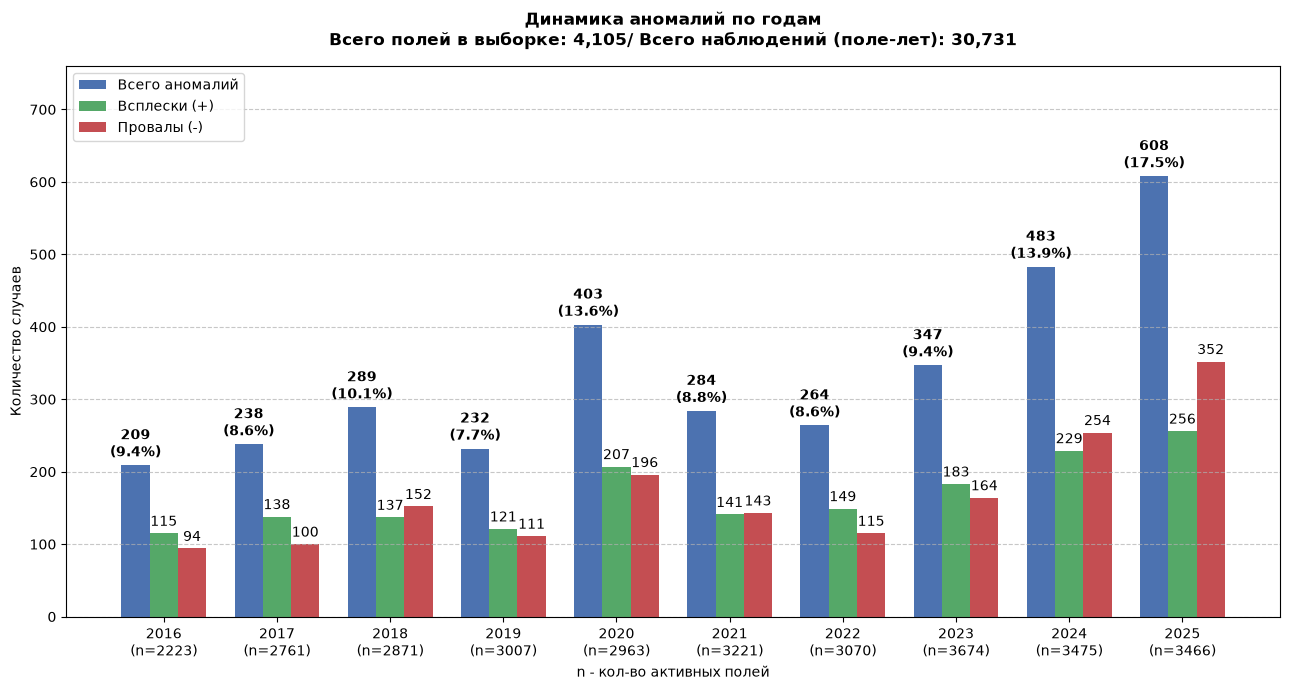

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Фильтр активных полей, без паров и пропусков)
active_records = df_merged[
    ~df_merged["anomaly_type"].isin(["Отдых (Пар)", "Нет данных"])
].copy()

# Статистика
total_unique_fields = active_records["field_id"].nunique()
total_record_count = len(active_records)

# Сводка по годам 
yearly_anomalies = (
    active_records.groupby("year")
    .agg(
        total_fields=("field_id", "count"),  
        spikes=("anomaly_type", lambda x: (x == "Всплеск (+)").sum()),
        drops=("anomaly_type", lambda x: (x == "Провал (-)").sum()),
        total=("is_anomaly", "sum"),
    )
    .reset_index()
)

# Расчет доли аномалий 
yearly_anomalies["pct_total"] = (
    yearly_anomalies["total"] / yearly_anomalies["total_fields"]
) * 100

# 4сам график
fig, ax = plt.subplots(figsize=(13, 7))

years = yearly_anomalies["year"].astype(str)
# В подписи дльавлю обьём
x_labels = [
    f"{yr}\n(n={tf})"
    for yr, tf in zip(years, yearly_anomalies["total_fields"])
]

x = np.arange(len(years))
width = 0.25

rects1 = ax.bar(
    x - width,
    yearly_anomalies["total"],
    width,
    label="Всего аномалий",
    color="#4C72B0",
)
rects2 = ax.bar(
    x,
    yearly_anomalies["spikes"],
    width,
    label="Всплески (+)",
    color="#55A868",
)
rects3 = ax.bar(
    x + width,
    yearly_anomalies["drops"],
    width,
    label="Провалы (-)",
    color="#C44E52",
)

# Оформление 
ax.set_ylabel("Количество случаев")
ax.set_title(
    f"Динамика аномалий по годам\n"
    f"Всего полей в выборке: {total_unique_fields:,}/ Всего наблюдений (поле-лет): {total_record_count:,}",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_xlabel("n - кол-во активных полей")
ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.7)

# Форм информативные подписи 
custom_labels_total = [
    f"{tot}\n({pct:.1f}%)"
    for tot, pct in zip(
        yearly_anomalies["total"], yearly_anomalies["pct_total"]
    )
]

# Вывод 
ax.bar_label(
    rects1, labels=custom_labels_total, padding=3, fontweight="bold"
)
ax.bar_label(rects2, padding=3)
ax.bar_label(rects3, padding=3)
ax.set_ylim(0, yearly_anomalies["total"].max() * 1.25)

plt.tight_layout()
plt.show()

**Промежуточный вывод**

- Отфильтрованы активные стабильные поля и для каждого года рассчитано кол-во полей (n), сумм. число аномалий, а также их характер.
- Построен столбчатый график (2016–2025 гг.), показывающий динамику аномалий для 4 105 полей (Стабильные и больше 3 лет истории, 30 731 наблюдение).


- Кол-во активных полей  в 2016 году (n = 2 223)  а  в период 2023–2025 гг. стабилизировалось на уровне $\sim 3 400\text{--}3 600$.

- В большинство лет (2016–2022) доля аномалий была в районе 7.7% – 10.1%. Исключением стал 2020 год, когда доля аномалий поднялась до 13.6% (403) - положительные (207) и отрицательные (196) скачки.

- Начиная с 2022 года наблюдается рост аномалий, особенно в 2024-2015 гг.
    - В 2024 году доля аномалий выросла до 13.9% (483).
    - В 2025 году достигнут пик - 17.5% (608 аномалий). 



- До 2023 года количество положительных аномалий часто превышало или было равно числу провалов, а в 2024–2025 гг. изменилось,  негативные аномалии стало больше. В 2025 году из 608 случаев 352 на провалы урожайности (58% от всех аномалий года) и 256 всплесков.


---

#### Отдельный год

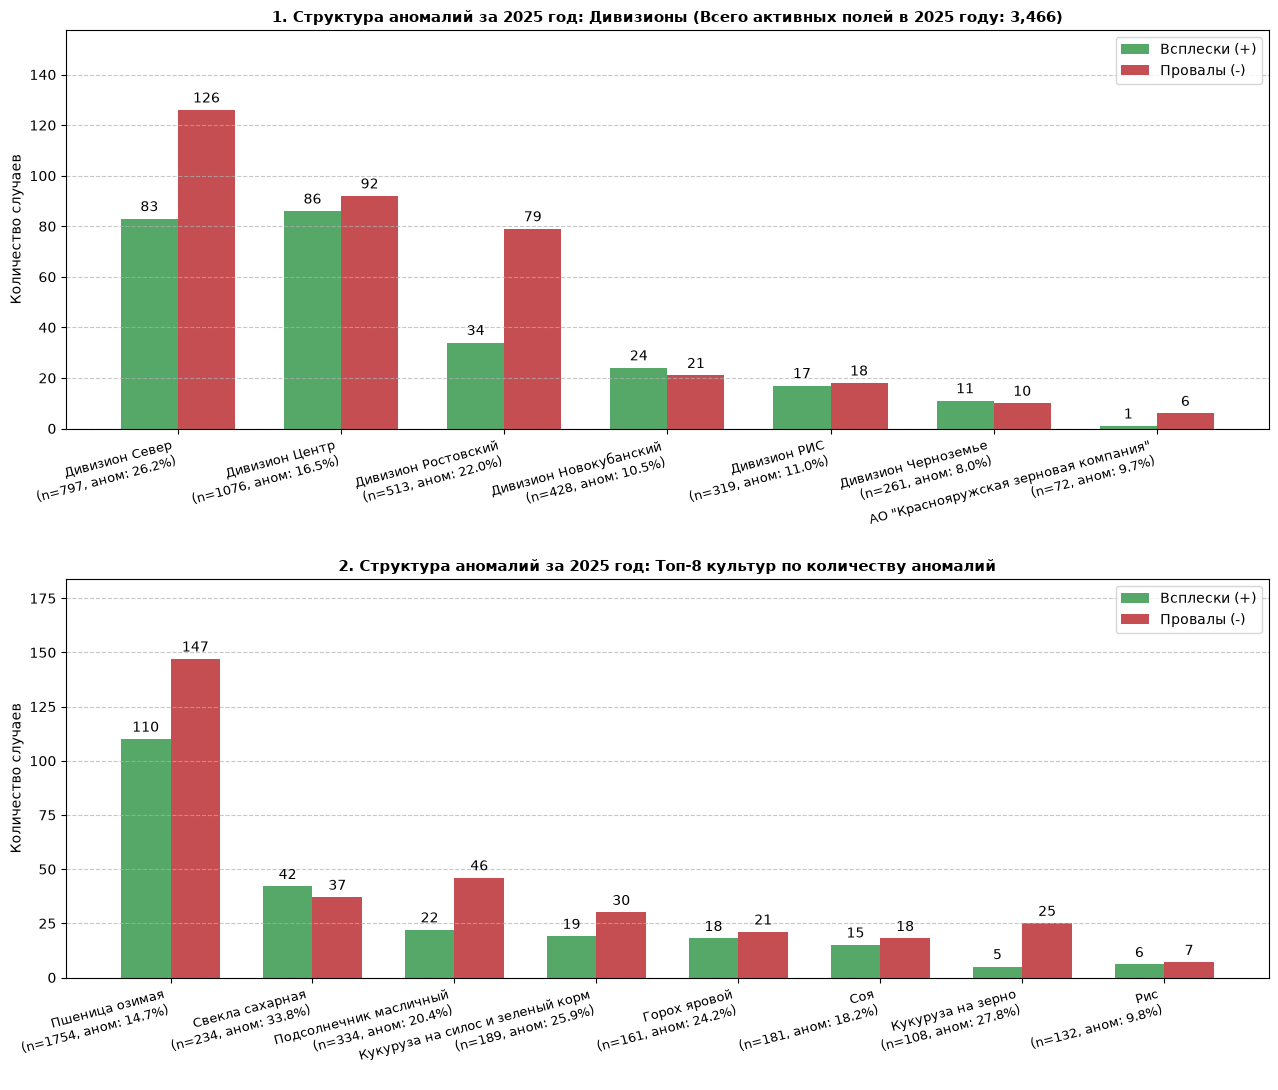

In [16]:
target_year = 2025

# Фильтр за выбранный год и общее число полей в этом году
df_year = active_records[active_records["year"] == target_year]
total_fields_year = len(df_year)

# Агрегация по дивизионам
year_by_division = (
    df_year.groupby("division")
    .agg(
        total_fields=("field_id", "count"),
        spikes=("anomaly_type", lambda x: (x == "Всплеск (+)").sum()),
        drops=("anomaly_type", lambda x: (x == "Провал (-)").sum()),
        total=("is_anomaly", "sum"),
    )
    .reset_index()
    .sort_values("total", ascending=False)
)
year_by_division["pct_anomaly"] = (
    year_by_division["total"] / year_by_division["total_fields"]
) * 100

# Агрегация по культурам 
year_by_crop = (
    df_year.groupby("crop_name")
    .agg(
        total_fields=("field_id", "count"),
        spikes=("anomaly_type", lambda x: (x == "Всплеск (+)").sum()),
        drops=("anomaly_type", lambda x: (x == "Провал (-)").sum()),
        total=("is_anomaly", "sum"),
    )
    .reset_index()
    .sort_values("total", ascending=False)
    .head(8)  # Ограничение до 8 для читаемости
)
year_by_crop["pct_anomaly"] = (
    year_by_crop["total"] / year_by_crop["total_fields"]
) * 100

# Построение 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 11))
width = 0.35

# -----------------
# 1- Дивизионы
x1 = np.arange(len(year_by_division))

rects1_1 = ax1.bar(
    x1 - width / 2,
    year_by_division["spikes"],
    width,
    label="Всплески (+)",
    color="#55A868",
)
rects1_2 = ax1.bar(
    x1 + width / 2,
    year_by_division["drops"],
    width,
    label="Провалы (-)",
    color="#C44E52",
)

# Формирование подписей оси 
div_labels = [
    f"{div}\n(n={tf}, аном: {pct:.1f}%)"
    for div, tf, pct in zip(
        year_by_division["division"],
        year_by_division["total_fields"],
        year_by_division["pct_anomaly"],
    )
]

ax1.set_ylabel("Количество случаев")
ax1.set_title(
    f"1. Структура аномалий за {target_year} год: Дивизионы (Всего активных полей в {target_year} году: {total_fields_year:,})",
    fontsize=11,
    fontweight="bold",
)
ax1.set_xticks(x1)
ax1.set_xticklabels(div_labels, rotation=15, ha="right", fontsize=9)
ax1.legend()
ax1.grid(axis="y", linestyle="--", alpha=0.7)
ax1.bar_label(rects1_1, padding=3)
ax1.bar_label(rects1_2, padding=3)

# Запас высоты оси Y для размещения меток
max_val_div = max(
    year_by_division["spikes"].max(), year_by_division["drops"].max()
)
ax1.set_ylim(0, max_val_div * 1.25)

# -----------------
# 2- Культуры
x2 = np.arange(len(year_by_crop))

rects2_1 = ax2.bar(
    x2 - width / 2,
    year_by_crop["spikes"],
    width,
    label="Всплески (+)",
    color="#55A868",
)
rects2_2 = ax2.bar(
    x2 + width / 2,
    year_by_crop["drops"],
    width,
    label="Провалы (-)",
    color="#C44E52",
)

crop_labels = [
    f"{crop}\n(n={tf}, аном: {pct:.1f}%)"
    for crop, tf, pct in zip(
        year_by_crop["crop_name"],
        year_by_crop["total_fields"],
        year_by_crop["pct_anomaly"],
    )
]

ax2.set_ylabel("Количество случаев")
ax2.set_title(
    f"2. Структура аномалий за {target_year} год: Топ-8 культур по количеству аномалий",
    fontsize=11,
    fontweight="bold",
)
ax2.set_xticks(x2)
ax2.set_xticklabels(crop_labels, rotation=15, ha="right", fontsize=9)
ax2.legend()
ax2.grid(axis="y", linestyle="--", alpha=0.7)
ax2.bar_label(rects2_1, padding=3)
ax2.bar_label(rects2_2, padding=3)

max_val_crop = max(year_by_crop["spikes"].max(), year_by_crop["drops"].max())
ax2.set_ylim(0, max_val_crop * 1.25)

plt.tight_layout()
plt.show()

**Промежуточный вывод**


- Дивизионы:
    - Соотношения провалов: Север (26.2% аномалий; 126 провалов и 83 всплеска) и Ростовский (22.0%; 79 провалов и 34 всплеска).
    - Крупнейший регион: Центр показывает 16.5% аномалий при равном балансе (86 всплесков / 92 провала).
    - Стабильные зоны: Черноземье (8.0%) и Краснояружская ЗК (9.7%).

- Культуры:
    - Пшеница озимая дает максимум аномалий (257 случаев, 14.7% от своего объема) с перевесом в сторону провалов (147).
    - Свекла сахарная (33.8% аномалий, чаще всплески) и Кукуруза на зерно (27.8%, сильный провал: 25 провалов и 5 всплесков).
    - Рис самая стабильная культура (9.8% аномалий).


---

In [17]:
# 10 самых сильных провалов
top_drops_list = (
    df_merged[df_merged["anomaly_type"] == "Провал (-)"]
    .sort_values("yield_ratio", ascending=True)
    [["field_id", "division", "crop_name", "productivity", "yield_ratio"]]
    .head(10)
)

print(f"10 полей с самыми сильными провалами в {target_year} году")
print(top_drops_list.to_string(index=False))

10 полей с самыми сильными провалами в 2025 году
field_id               division         crop_name  productivity  yield_ratio
   26467 Дивизион Новокубанский    Пшеница озимая      5.350000     0.119901
   13788 Дивизион Новокубанский    Пшеница озимая      9.060000     0.170686
   25883    Дивизион Черноземье               Соя      3.550000     0.201877
   13899 Дивизион Новокубанский    Пшеница озимая      9.120000     0.204393
   13877 Дивизион Новокубанский    Пшеница озимая     11.700000     0.214600
   13779           Дивизион РИС               Соя      2.476316     0.218837
   14032 Дивизион Новокубанский    Пшеница озимая     10.760000     0.241147
   22327         Дивизион Центр Кукуруза на зерно      7.200000     0.246660
   13909 Дивизион Новокубанский    Пшеница озимая     11.240000     0.251905
   14060 Дивизион Новокубанский    Пшеница озимая     12.290000     0.258737


---

## Анализ влияния предшественников

---
### Описание


#### Расчёт


**Для оценки влияния культуры‑предшественника на урожайность следующей культуры исп. индекс урожайности.**

$$
\text{yield_ratio} = \frac{\text{Урожайность поля}}{\text{Медианная урожайность этой же культуры в этом же дивизионе в этом же году}}
$$

##### Интерпретация:

| Значение | Смысл |
|----------|-------|
| `= 1.0` | Поле сработало на уровне медианы. |
| `> 1.0` | Поле сработало лучше. |
| `< 1.0` | Поле сработало хуже. |


**Общая медиана по культуре** – это нормальный уровень yield_ratio для данной культуры за все годы. На графиках она обозначена красной пунктирной линией.

##### Фильтрация выборки

Исп. только те пары "Предшественник - Культура", по которым накоплено мин. 30 наблюдений (можно изменять).

---

#### Чтение графиков

##### 1)  Медианное влияние

Этот график показывает средний результат при посеве после конкретного предшественника. Столбцы отсортированы от лучшего к худшему.

##### Элементы:

- Высота столбца – медианный yield_ratio.  
  Если столбец выше красной линии – предшественник в среднем положительно влияет на культуру.

- Подписи:
  1. Значение медианы.
  2. Количество наблюдений.
  3. `> Norm: ...%` – доля случаев, когда поле сработало лучше среднего.

---

#### Распределение и стабильность

Этот график показывает средний результат, и разброс. Медиана из первого графика здесь отображается как чёрная линия внутри "ящика".

##### Элементы:

- "Ящик" (от 25% до 75% квантиля) – показывает основную часть результатов:
  - Узкий ящик - предшественник даёт стабильный и предсказуемый результат.
  - Широкий ящик - значения не стабильны.

- "Усы ящика" (линии сверху и снизу) – границы нормальных колебаний. Всё, что за пределами усов – аномалии.

- Красная точка внутри ящика – среднее арифметическое.  
  Если красная точка смещена относительно чёрной линии (медианы), это говорит о перекосе данных (например, несколько полей дали аномально высокий урожай, потянув среднее вверх).

---

График медианы сохранен: prev_crop\median_prev_crop.png


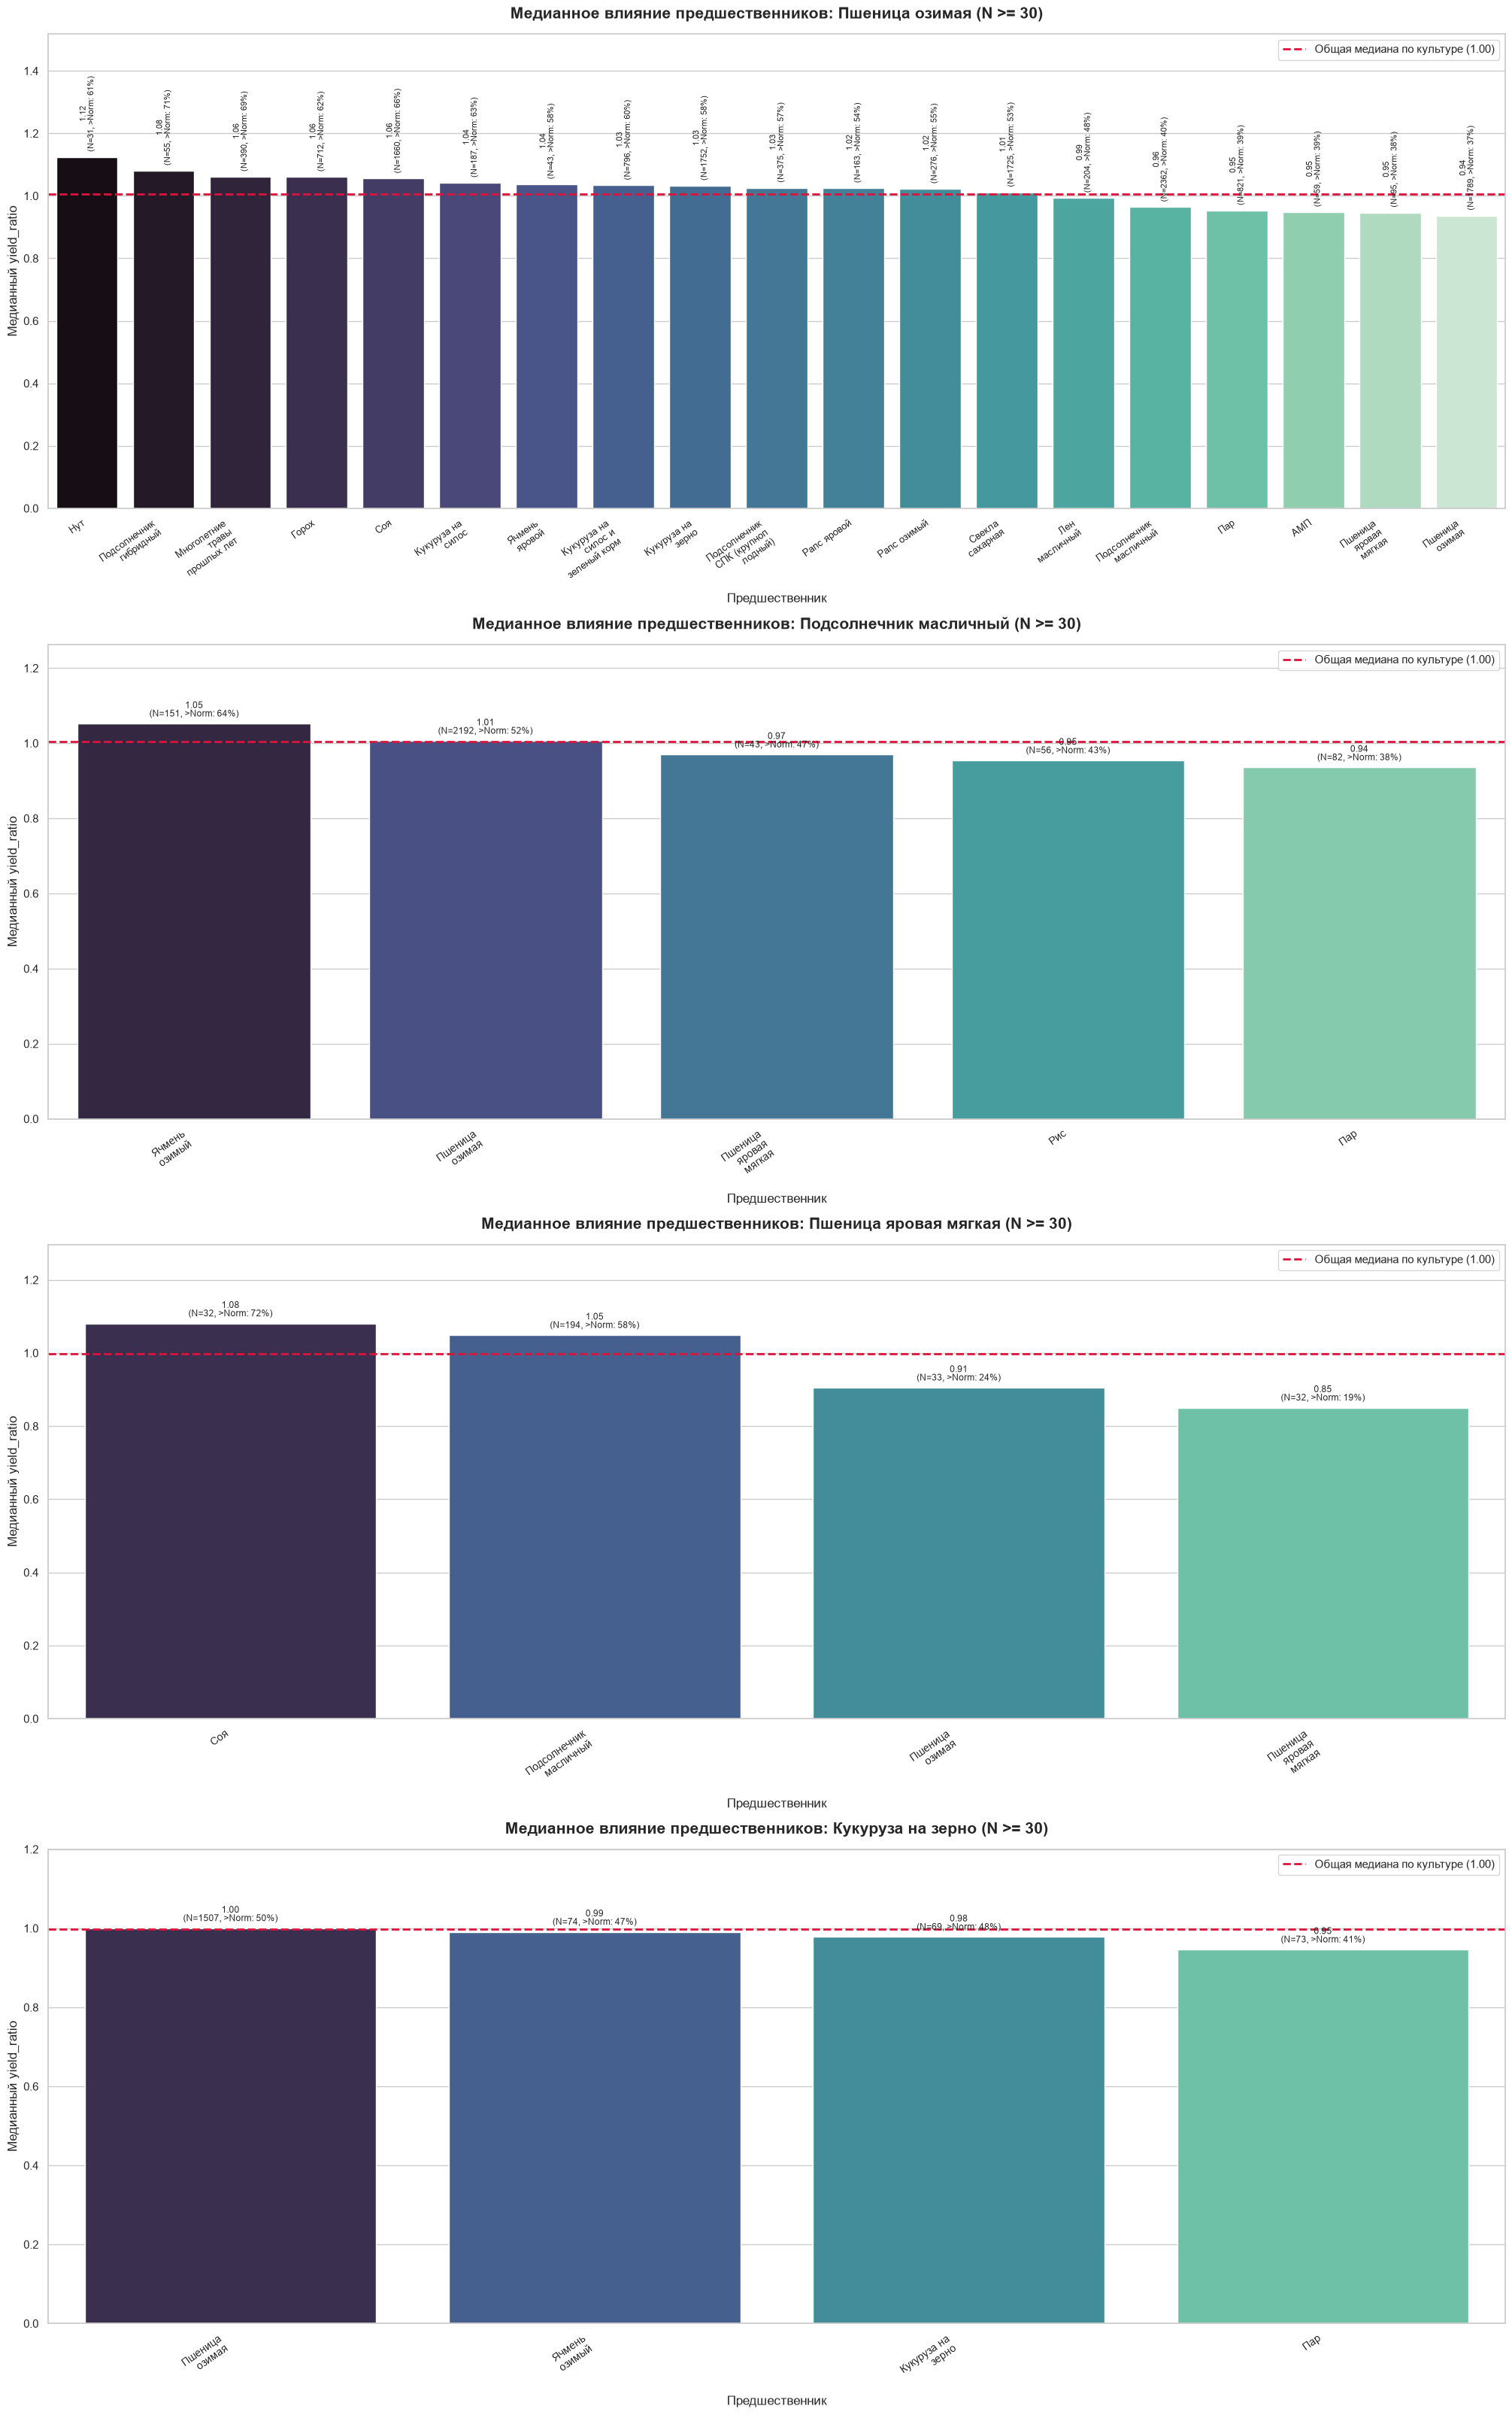

График распределения сохранен: prev_crop\boxplot_prev_crop.png


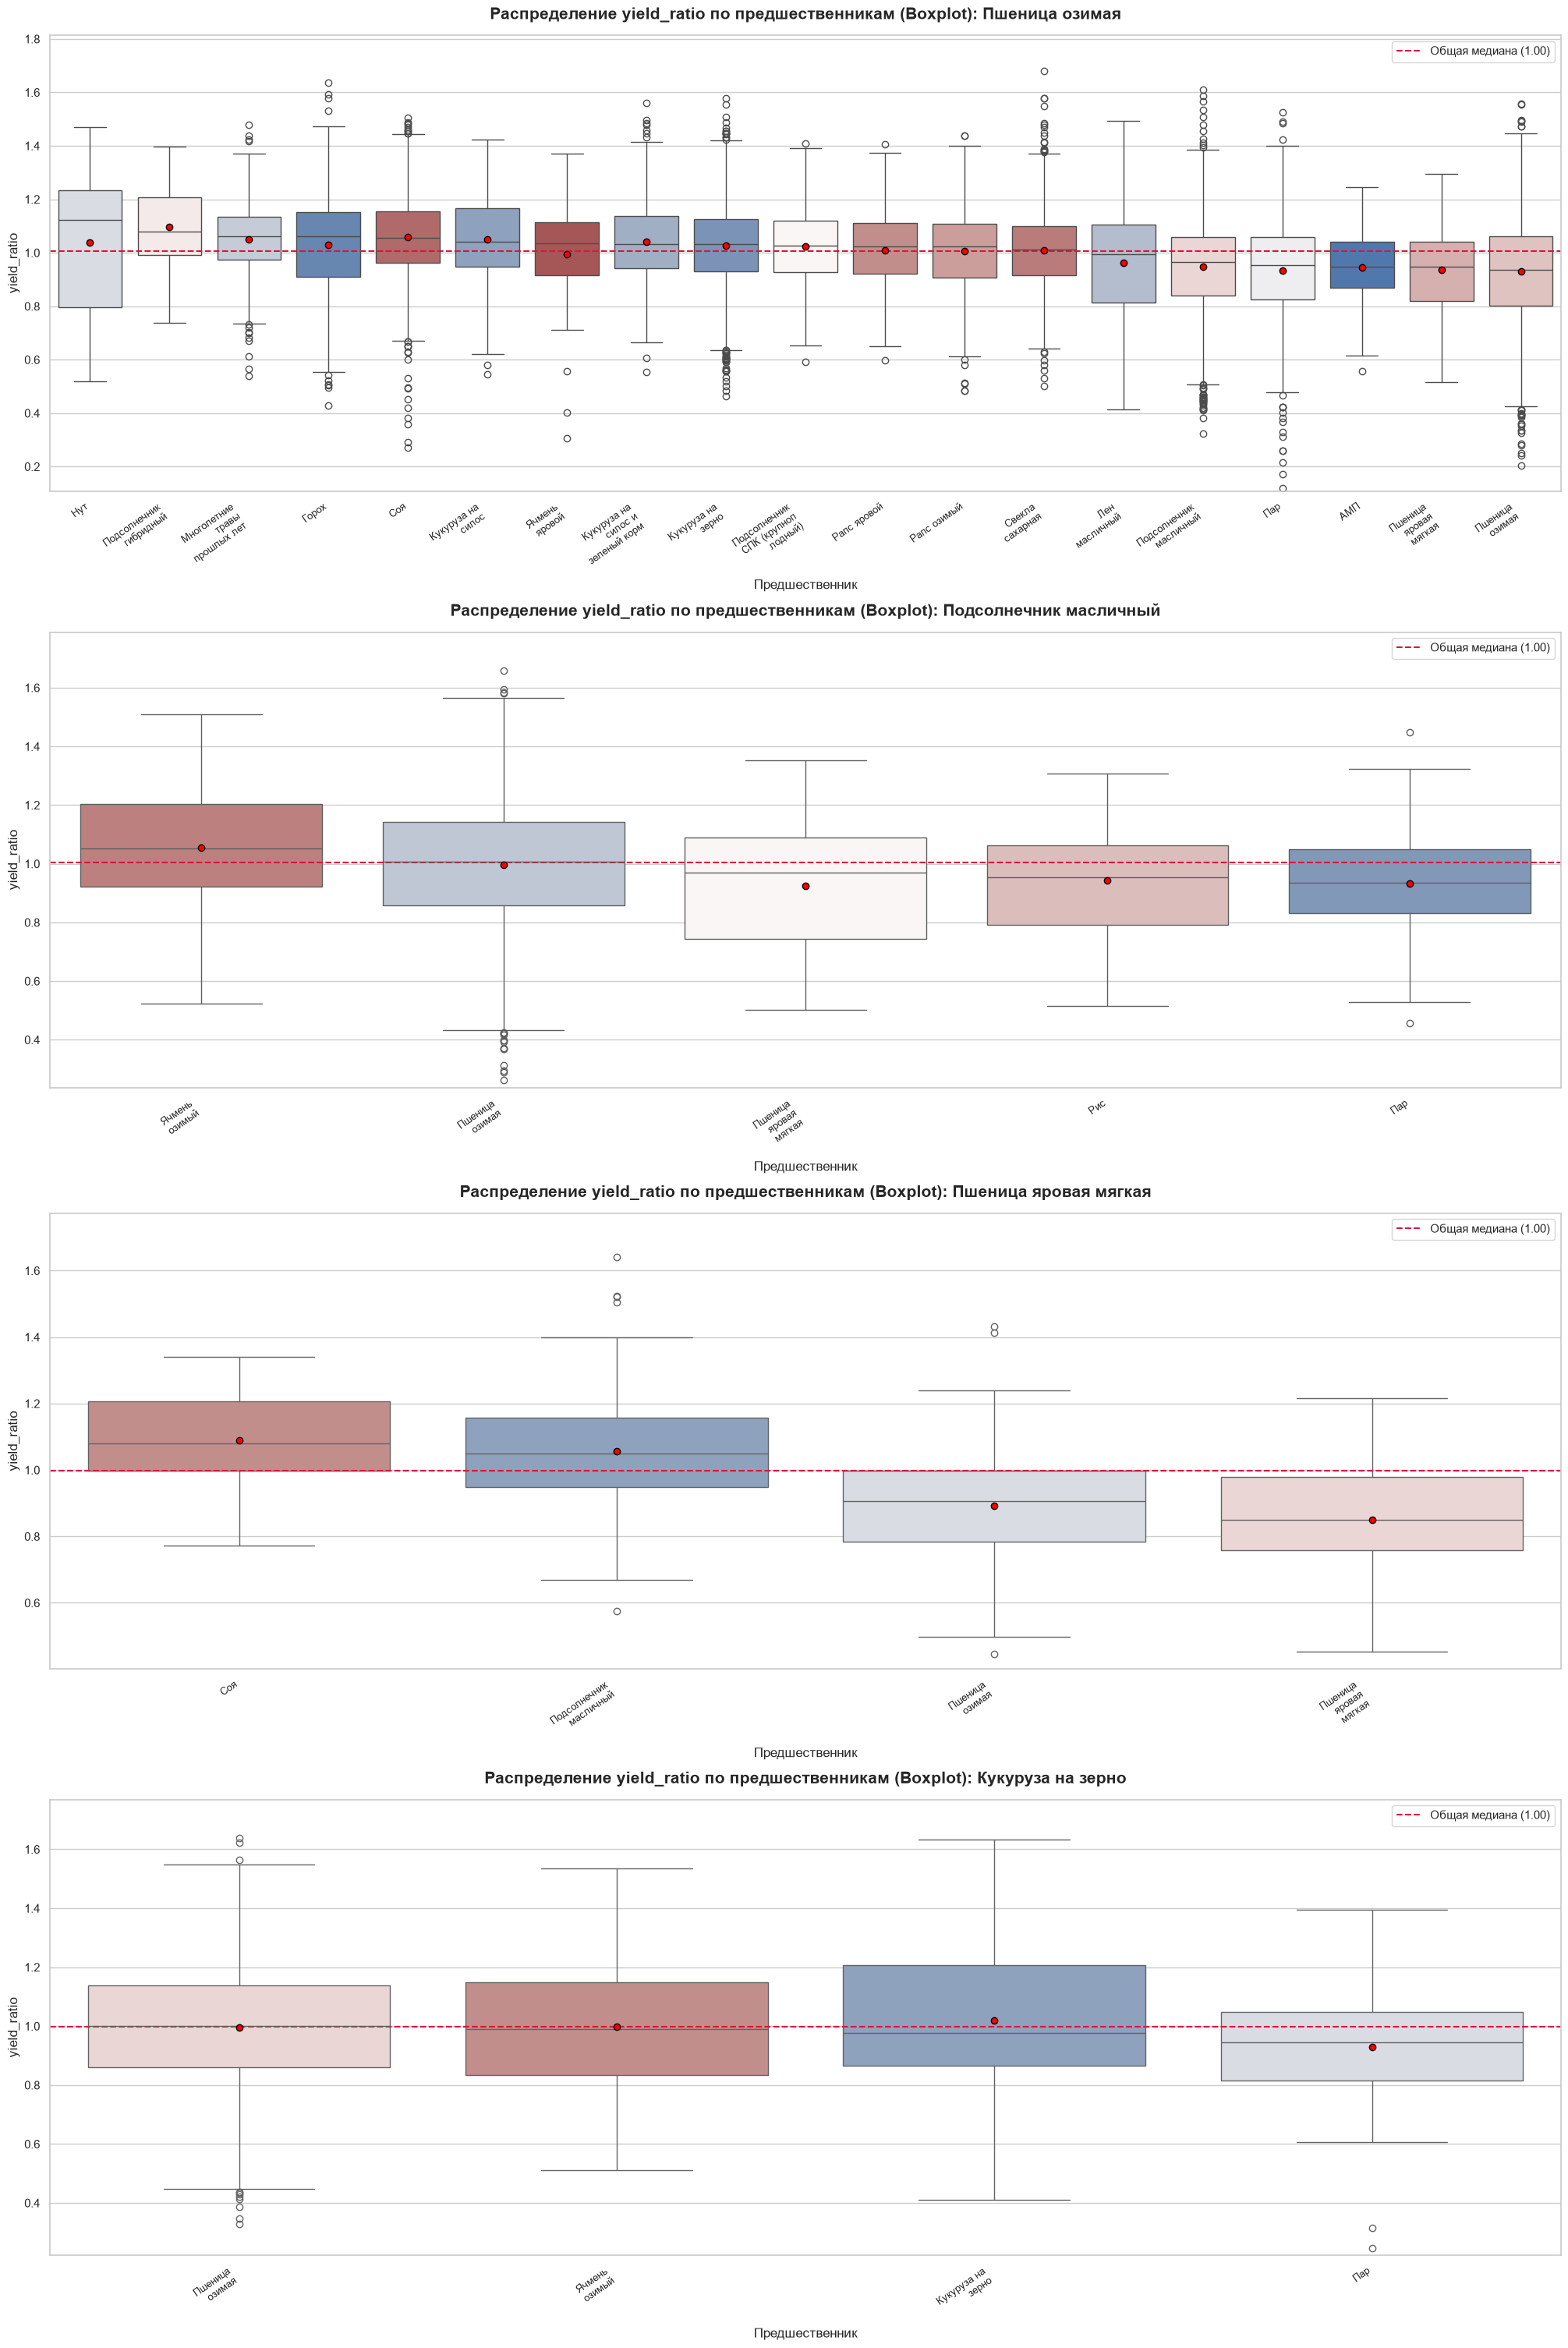

In [18]:
# Настройка
OUTPUT_DIR = "prev_crop"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CROP_COL = "crop_name"
PREV_CROP_COL = "prev_crop"
YIELD_COL = "yield_ratio"

TARGET_CROPS = [
    "Пшеница озимая",
    "Подсолнечник масличный",
    "Пшеница яровая мягкая",
    "Кукуруза на зерно",
]
MIN_SAMPLES = 30

# Фильтр
df_work = df_merged[df_merged[CROP_COL].isin(TARGET_CROPS)].copy()

counts = df_work.groupby([CROP_COL, PREV_CROP_COL])[YIELD_COL].count()
valid_pairs = counts[counts >= MIN_SAMPLES].index

df_filtered = (
    df_work.set_index([CROP_COL, PREV_CROP_COL]).loc[valid_pairs].reset_index()
)

pred_medians = (
    df_filtered.groupby([CROP_COL, PREV_CROP_COL])[YIELD_COL]
    .agg(
        median="median",
        count="count",
        pct_above=lambda x: (x.dropna() >= 1.00).mean() * 100 if len(x.dropna()) > 0 else 0,
    )
    .reset_index()
)
overall_medians = df_work.groupby(CROP_COL)[YIELD_COL].median().to_dict()

# -----------------------------------------------
# 1: Медианная урожайность
sns.set_theme(style="whitegrid")

fig1, axes1 = plt.subplots(
    len(TARGET_CROPS),
    1,
    figsize=(20, 8 * len(TARGET_CROPS)),
    constrained_layout=True,
)

for idx, culture in enumerate(TARGET_CROPS):
    ax = axes1[idx] if len(TARGET_CROPS) > 1 else axes1
    sub_data = pred_medians[pred_medians[CROP_COL] == culture].sort_values(
        by="median", ascending=False
    )

    if sub_data.empty:
        ax.set_title(
            f"Культура: {culture} (нет данных с N >= {MIN_SAMPLES})",
            fontsize=12,
        )
        continue

    n_items = len(sub_data)
    is_dense = n_items > 10

    sub_data = sub_data.copy()
    sub_data["prev_crop_wrapped"] = sub_data[PREV_CROP_COL].apply(
        lambda x: textwrap.fill(str(x), width=12)
    )

    sns.barplot(
        data=sub_data,
        x="prev_crop_wrapped",
        y="median",
        ax=ax,
        palette="mako",
        hue="prev_crop_wrapped",
        legend=False,
    )

    benchmark = overall_medians[culture]
    ax.axhline(
        benchmark,
        color="crimson",
        linestyle="--",
        linewidth=2,
        label=f"Общая медиана по культуре ({benchmark:.2f})",
    )

    ax.set_title(
        f"Медианное влияние предшественников: {culture} (N >= {MIN_SAMPLES})",
        fontsize=15,
        fontweight="bold",
        pad=15,
    )
    ax.set_xlabel("Предшественник", fontsize=12, labelpad=10)
    ax.set_ylabel("Медианный yield_ratio", fontsize=12)

    plt.setp(
        ax.get_xticklabels(),
        rotation=35,
        ha="right",
        fontsize=9 if is_dense else 10,
    )
    ax.legend(loc="upper right", frameon=True, fontsize=11)

    max_height = sub_data["median"].max()
    ax.set_ylim(0, max_height * (1.35 if is_dense else 1.20))

    for i, (_, row) in enumerate(sub_data.iterrows()):
        height = row["median"]
        if not np.isnan(height):
            ax.annotate(
                f"{height:.2f}\n(N={int(row['count'])}, >Norm: {row['pct_above']:.0f}%)",
                xy=(i, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8 if is_dense else 8.5,
                rotation=90 if is_dense else 0,
                linespacing=1.1,
            )

file_path_bar = os.path.join(OUTPUT_DIR, "median_prev_crop.png")
fig1.savefig(file_path_bar, dpi=300, bbox_inches="tight")
print(f"График медианы сохранен: {file_path_bar}")
plt.show()


# -----------------------------------------------
# 2: Boxplot распред
fig2, axes2 = plt.subplots(
    len(TARGET_CROPS),
    1,
    figsize=(20, 7.5 * len(TARGET_CROPS)),
    constrained_layout=True,
)

for idx, culture in enumerate(TARGET_CROPS):
    ax = axes2[idx] if len(TARGET_CROPS) > 1 else axes2
    crop_data = df_filtered[df_filtered[CROP_COL] == culture].copy()

    crop_data["prev_crop_wrapped"] = crop_data[PREV_CROP_COL].apply(
        lambda x: textwrap.fill(str(x), width=12)
    )

    order = [
        textwrap.fill(str(x), width=12)
        for x in crop_data.groupby(PREV_CROP_COL)[YIELD_COL]
        .median()
        .sort_values(ascending=False)
        .index
    ]

    sns.boxplot(
        data=crop_data,
        x="prev_crop_wrapped",
        y=YIELD_COL,
        order=order,
        ax=ax,
        palette="vlag",
        hue="prev_crop_wrapped",
        legend=False,
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "red",
            "markeredgecolor": "black",
        },
    )

    benchmark = overall_medians[culture]
    ax.axhline(benchmark, color="crimson", linestyle="--", linewidth=1.5, label=f"Общая медиана ({benchmark:.2f})")
    ax.legend(loc="upper right", fontsize=11)
    ax.set_title(
        f"Распределение yield_ratio по предшественникам (Boxplot): {culture}",
        fontsize=15,
        fontweight="bold",
        pad=15,
    )
    ax.set_xlabel("Предшественник", fontsize=12, labelpad=10)
    ax.set_ylabel("yield_ratio", fontsize=12)

    max_val = crop_data[YIELD_COL].max()
    ax.set_ylim(bottom=crop_data[YIELD_COL].min() * 0.9, top=max_val * 1.08)

    plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9.5)

file_path_box = os.path.join(OUTPUT_DIR, "boxplot_prev_crop.png")
fig2.savefig(file_path_box, dpi=300, bbox_inches="tight")
print(f"График распределения сохранен: {file_path_box}")
plt.show()

In [19]:
# для раскраски таблицы
def highlight_performance(s):
    is_high = s > 1.05
    is_low = s < 0.95
    return ['background-color: #d4edda' if v else 'background-color: #f8d7da' if v2 else '' 
            for v, v2 in zip(is_high, is_low)]

# Создаем копию д
display_df = pred_medians.copy()

# Переименуем колонки 
display_df.columns = ["Культура", "Предшественник", "Медиана Yield Ratio", "Кол-во наблюдений (N)", "% случаев выше нормы"]

# Применяем 
styled_table = (
    display_df.style
    .format({
        "Медиана Yield Ratio": "{:.2f}",
        "% случаев выше нормы": "{:.1f}%"
    })
    .background_gradient(cmap='RdYlGn', subset=["Медиана Yield Ratio", "% случаев выше нормы"])
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])
)

display(styled_table)

,Культура,Предшественник,Медиана Yield Ratio,Кол-во наблюдений (N),% случаев выше нормы
0,Кукуруза на зерно,Кукуруза на зерно,0.98,69,47.8%
1,Кукуруза на зерно,Пар,0.95,73,41.1%
2,Кукуруза на зерно,Пшеница озимая,1.00,1507,50.4%
3,Кукуруза на зерно,Ячмень озимый,0.99,74,47.3%
4,Подсолнечник масличный,Пар,0.94,82,37.8%
5,Подсолнечник масличный,Пшеница озимая,1.01,2192,52.4%
6,Подсолнечник масличный,Пшеница яровая мягкая,0.97,43,46.5%
7,Подсолнечник масличный,Рис,0.95,56,42.9%
8,Подсолнечник масличный,Ячмень озимый,1.05,151,63.6%
9,Пшеница озимая,АМП,0.95,59,39.0%


### Анализ графиков 

##### 1. Пшеница озимая

###### Медианные показатели

- Наиболее благоприятными предшественниками являются:  
  - *Нут* – индекс `1.12` (прирост **+12%**)  
  - *Горох* – индекс `1.06` (прирост **+6%**)  
  - *Соя* – индекс `1.06` (прирост **+6%**)  
  - *Подсолнечник гибридный* – `1.08` (прирост **+8%**)  
- Пшеница озимая и яровая показывают снижение урожайности (индексы `0.94 и 0.95`, просадка на **5–6%**).

##### Распределение 

- Для *Сои* (*N = 1660*), *Гороха* (*N = 712*) и *Подсолнечник гибридный* (*N = 55*) - межквартильные размахи расположены в  основном выше нормы `1.00`,это показывает  низкий риск и предсказуемость.  
- У монокультуры ящик смещён вниз.

---

#### 2. Подсолнечник масличный

##### Медианные показатели
  
- Лучшие предшественники – *Ячмень озимый* (индекс `1.05`, прирост **+5%**) и *Пшеница озимая*  (`1.01`).  
- Наихудшие результаты зафиксированы после *Пара* (`0.93`) и *Риса* (`0.95`).

##### Распределение 

- *Пшеница озимая* показывает симметричное распределением без провалов (медиана и среднее совпадают).  
- У *Ячмень озимый* размах находится выше `1.00`, это показывает положительный эффект.

---

#### 3. Пшеница яровая мягкая

##### Медианные показатели 

- Наиболее благоприятными предшественниками являются: 
  - *Соя* – индекс `1.08` (прирост **+8%**)  
  - *Подсолнечник масличный* – индекс `1.05` (прирост **+5%**)  
- Повторный посев приводит к падению до `0.85` (просадка **–15%**).

##### Распределение

- *Соя* показывает диапазон от `1.00` до `1.20`, то есть **75%** полей дают результат на уровне или выше нормы.  
- При монокультуре весь ящик расположен ниже отметки `1.00`, это говорит о риске ухудшения урожая.

---

#### 4. Кукуруза на зерно

##### Медианные показатели 

- Тут видна низкая чувствительность к смене предшественника.  
- Основной массив данных по *Пшенице озимой* (*N = 1507*) показывает норму (`1.00`).  
- Посев *Пар* даёт просадку до `0.95`.

##### Распределение

- Распределение компактное и есть совпадение медиан со средними значениями для всех предшественников, что говорит о стабильности и предсказуемости.

---

## Химия

### Загрузка и проверка структуры

In [20]:
file_path = os.path.join("data_input", "Акты архивные.xlsx")
df_chem_raw = pd.read_excel(file_path)

print("Размерность сырых данных:", df_chem_raw.shape)
print("\nКолонки и типы данных:")
print(df_chem_raw.info())

print("\nПропуски по колонкам:")
print(df_chem_raw.isna().sum())

display(df_chem_raw.head())

Размерность сырых данных: (779824, 17)

Колонки и типы данных:
<class 'pandas.DataFrame'>
RangeIndex: 779824 entries, 0 to 779823
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   ID                              779824 non-null  str           
 1   Дата                            779824 non-null  datetime64[us]
 2   Номер                           779824 non-null  str           
 3   Проведен                        779824 non-null  int64         
 4   Номенклатура ID                 779824 non-null  object        
 5   Номенклатура                    779805 non-null  str           
 6   Вид Номенклатуры                779805 non-null  str           
 7   Ед Изм                          779804 non-null  str           
 8   Количество                      779824 non-null  float64       
 9   Счет                            779806 non-null  str           
 10  Стру

,ID,Дата,Номер,Проведен,Номенклатура ID,Номенклатура,Вид Номенклатуры,Ед Изм,Количество,Счет,Структура Посевных Площадей ID,Площадь Поля,Норма Га,Вид Работ,Поле,Культура,Год
0,8000AEDD76F2710045BF1430E0475291,2021-06-09 12:00:00,АРРС-000628,1,8DB724B6FD9DDED011E4D37B9636AF36,Гумат калия Суфлер,Материалы: Удобрения на основе гуминовых кислот,л,25.200,"Удобрения, средства защиты растений и животных...",AB7188D7F6D4F45E11EAB6C44CC80D87,84.0,0.300,NaN,61-33-БКРЕ-029,Пшеница озимая,2021.0
1,8001DA7F4C74F23246DB5287E1C753AB,2021-04-01 12:00:00,АРРЗ-000131,1,AB41B0262812AB2511E962A4B1489EBD,Аммиачная селитра,Материалы: Удобрения минеральные,кг,9200.000,"Удобрения, средства защиты растений и животных...",AB7188D7F6D4F45E11EAB554C06491E7,46.0,200.000,NaN,61-30-ПОЛВ-024,Свекла сахарная,2021.0
2,8004A254B430409A4C0FF73CA4619A69,2022-04-12 12:00:00,АРРЗ-000361,1,8DB724B6FD9DDED011E4E41F45B0FF8C,"Гранат, ВДГ",Материалы: Гербициды,не исп,1.395,"Удобрения, средства защиты растений и животных...",AB8088D7F6D4F45E11EBDB6732FBAAC7,93.0,0.015,NaN,61-30-ЖУКВ-027,Ячмень озимый,2022.0
3,8005A5DF565ACE6F45F62D298F3A4D6B,2021-04-30 12:00:00,АРРД-000045,1,9FD024B6FD9DDED011E2904E4F9409AB,"Примадонна, СЭ",Материалы: Гербициды,л,58.200,"Удобрения, средства защиты растений и животных...",AB7188D7F6D4F45E11EAB6AEC6DEF590,97.0,0.600,NaN,РДРАЗ70,Ячмень озимый,2021.0
4,80090F7206237F964E4A92162F799819,2021-04-04 12:00:00,АРКК-000008,1,AB41B0262812AB2511E962A4B1489EBD,Аммиачная селитра,Материалы: Удобрения минеральные,кг,8020.000,"Удобрения, средства защиты растений и животных...",AB7188D7F6D4F45E11EAB6AC38B5F6E5,56.0,143.214,NaN,61-06-ПОЗД-030,Пшеница озимая,2021.0


### Фильтр колонок и агрегация по полям
**Так как на одно поле в течение года удобрения могли вноситься в несколько, сводим данные к уровню "одно поле - один год"**

In [21]:
# чек всех уникальных значений с количеством записей
print("Все виды номенклатуры")
display(df_chem_raw["Вид Номенклатуры"].value_counts(dropna=False).reset_index())

# чек что попадет в Удобрения, что в СЗР, а что останется вне групп
df_cats = df_chem_raw[["Вид Номенклатуры"]].drop_duplicates().dropna().copy()

df_cats["is_fert"] = df_cats["Вид Номенклатуры"].str.contains(
    "Удобрения|Микроудобрения", case=False, na=False
)
df_cats["is_prot"] = df_cats["Вид Номенклатуры"].str.contains(
    "Гербициды|Фунгициды|Инсектициды|Протравители|Десиканты|Адьюванты|Родентициды|Фумиганты|Регуляторы роста",
    case=False,
    na=False,
)

def assign_group(row):
    if row["is_fert"] and row["is_prot"]:
        return "ОБЕ ГРУППЫ (Нужна проверка)"
    if row["is_fert"]:
        return "Удобрения"
    if row["is_prot"]:
        return "Средства защиты (СЗР)"
    return "ПРОЧЕЕ (Не попадет никуда)"

df_cats["Итоговая группа"] = df_cats.apply(assign_group, axis=1)

print("\nКатегории")
display(df_cats[["Вид Номенклатуры", "Итоговая группа"]].sort_values(by="Итоговая группа"))

Все виды номенклатуры


,Вид Номенклатуры,count
0,Материалы: Гербициды,177537
1,Материалы: Удобрения минеральные,171046
2,Материалы: Инсектициды и акарициды,103897
3,Материалы: Фунгициды,79300
4,"Материалы: Микроудобрения, стимуляторы",66095
5,Материалы: Удобрения на основе гуминовых кислот,60124
6,Материалы: Родентициды,41896
7,Материалы: Адьюванты,36183
8,Материалы: Удобрения комплексные с микроэлемен...,21454
9,Материалы: Регуляторы роста растений,7321



Категории


,Вид Номенклатуры,Итоговая группа
370,Материалы: Прочие материалы,ПРОЧЕЕ (Не попадет никуда)
6733,Материалы: Прочие средства защиты растений,ПРОЧЕЕ (Не попадет никуда)
16312,Сырье,ПРОЧЕЕ (Не попадет никуда)
56387,Материалы: Дезсредства,ПРОЧЕЕ (Не попадет никуда)
56390,Материалы: Инструменты и материалы,ПРОЧЕЕ (Не попадет никуда)
166740,Материалы: Инвентарь и хозяйст-ные принадлежности,ПРОЧЕЕ (Не попадет никуда)
206178,Материалы: Запасные части,ПРОЧЕЕ (Не попадет никуда)
241764,Материалы: Мелиоранты почвы известковые,ПРОЧЕЕ (Не попадет никуда)
342132,Готовая продукция - 10.17,ПРОЧЕЕ (Не попадет никуда)
370052,Товар,ПРОЧЕЕ (Не попадет никуда)


In [22]:
MAIN_FIELD_COL = "field_name"

# Оставляем только нужные колонки
cols_to_keep = [
    "Поле",
    "Год",
    "Дата",
    "Номенклатура",
    "Вид Номенклатуры",
    "Норма Га",
]
df_chem = df_chem_raw[cols_to_keep].copy()

# Приводим год к числовому формату
year_numeric = pd.to_numeric(df_chem["Год"], errors="coerce")
year_from_date = pd.to_datetime(df_chem["Дата"], errors="coerce").dt.year
df_chem["year"] = year_numeric.fillna(year_from_date)

# Очищаем ключи
df_chem = df_chem.dropna(subset=["Поле", "year"]).copy()
df_chem["field_name_clean"] = (
    df_chem["Поле"].astype(str).str.strip().str.upper()
)
df_chem["year"] = df_chem["year"].astype(int)

# Размечаем Удобрения и СЗР с полным охватом подстрок
is_fert = df_chem["Вид Номенклатуры"].str.contains(
    "Удобрен|Микроудобрен", case=False, na=False
)
is_prot = df_chem["Вид Номенклатуры"].str.contains(
    "Гербицид|Фунгицид|Инсектицид|Протравител|Десикант|Адьювант|Адъювант|Родентицид|Фумигант|Регулятор|Защит",
    case=False,
    na=False,
)

df_chem["is_fertilizer"] = is_fert.astype(int)
df_chem["is_protection"] = is_prot.astype(int)

# Подготовка временных колонок для раздельного подсчета
df_chem["fert_norma"] = df_chem["Норма Га"].where(is_fert, 0)
df_chem["prot_norma"] = df_chem["Норма Га"].where(is_prot, 0)
df_chem["fert_name"] = df_chem["Номенклатура"].where(is_fert, np.nan)
df_chem["prot_name"] = df_chem["Номенклатура"].where(is_prot, np.nan)

# Агрегация до уровня "одно поле - один год"
df_chem_agg = (
    df_chem.groupby(["field_name_clean", "year"])
    .agg(
        # Блок Удобрений
        has_fertilizer=("is_fertilizer", "max"),
        fert_norma_ha=("fert_norma", "sum"),
        fert_count=("fert_name", "nunique"),
        fertilizers_list=(
            "fert_name",
            lambda x: ", ".join(sorted(x.dropna().astype(str).unique()))
            if x.dropna().nunique() > 0
            else "—",
        ),
        # Блок Защиты (СЗР)
        has_protection=("is_protection", "max"),
        prot_norma_ha=("prot_norma", "sum"),
        prot_count=("prot_name", "nunique"),
        protection_list=(
            "prot_name",
            lambda x: ", ".join(sorted(x.dropna().astype(str).unique()))
            if x.dropna().nunique() > 0
            else "—",
        ),
    )
    .reset_index()
)

print(f"Всего записей: {len(df_chem):,}")
print(f"Пар [поле-год]: {len(df_chem_agg):,}")

Всего записей: 776,834
Пар [поле-год]: 64,543


### Объединение

In [23]:
# Приводим ключи к единому регистру
for df in [df_clean, df_merged]:
    df[MAIN_FIELD_COL] = (
        df[MAIN_FIELD_COL].astype(str).str.strip().str.upper()
    )
    df["year"] = df["year"].astype(int)

# Объединяем
df_clean_study = df_clean.merge(
    df_chem_agg,
    left_on=[MAIN_FIELD_COL, "year"],
    right_on=["field_name_clean", "year"],
    how="left",
)

df_merged_study = df_merged.merge(
    df_chem_agg,
    left_on=[MAIN_FIELD_COL, "year"],
    right_on=["field_name_clean", "year"],
    how="left",
)

# Заполняем пропуски для необработанных полей
for df in [df_clean_study, df_merged_study]:
    # Удобрения
    df["has_fertilizer"] = df["has_fertilizer"].fillna(0).astype(int)
    df["fert_norma_ha"] = df["fert_norma_ha"].fillna(0)
    df["fert_count"] = df["fert_count"].fillna(0).astype(int)
    df["fertilizers_list"] = (
        df["fertilizers_list"].replace("", "—").fillna("—")
    )

    # СЗр
    df["has_protection"] = df["has_protection"].fillna(0).astype(int)
    df["prot_norma_ha"] = df["prot_norma_ha"].fillna(0)
    df["prot_count"] = df["prot_count"].fillna(0).astype(int)
    df["protection_list"] = df["protection_list"].replace("", "—").fillna("—")

# Удаляем тех колонку
df_clean_study.drop(
    columns=["field_name_clean"], inplace=True, errors="ignore"
)
df_merged_study.drop(
    columns=["field_name_clean"], inplace=True, errors="ignore"
)

print('готово')

готово


### Проверка бъединения

In [24]:
def print_merge_stats(df_result, df_name):
    total_rows = len(df_result)
    matched_fert = (df_result["has_fertilizer"] == 1).sum()
    matched_prot = (df_result["has_protection"] == 1).sum()

    pct_fert = (matched_fert / total_rows) * 100 if total_rows > 0 else 0
    pct_prot = (matched_prot / total_rows) * 100 if total_rows > 0 else 0

    print(f"Статистика: {df_name}")
    print(f"Всего строк: {total_rows:,}")
    print(f"С удобрениями: {matched_fert:,} ({pct_fert:.2f}%)")
    print(f"Со средствами защиты (СЗР): {matched_prot:,} ({pct_prot:.2f}%)\n")


def validate_dataset_structures(
    df_clean_raw,
    df_merged_raw,
    df_chem_agg_data,
    df_clean_res,
    df_merged_res,
    field_col,
):
    print("Проверка ключей")
    clean_dups = df_clean_raw.duplicated(subset=[field_col, "year"]).sum()
    merged_dups = df_merged_raw.duplicated(subset=[field_col, "year"]).sum()
    chem_dups = df_chem_agg_data.duplicated(
        subset=["field_name_clean", "year"]
    ).sum()

    print(f"Дубликаты [поле, год] в df_clean: {clean_dups}")
    print(f"Дубликаты [поле, год] в df_merged: {merged_dups}")
    print(f"Дубликаты [поле, год] в df_chem_agg: {chem_dups}\n")

    print("Проверка сохранения объема")
    clean_len_match = len(df_clean_raw) == len(df_clean_res)
    merged_len_match = len(df_merged_raw) == len(df_merged_res)
    print(
        f"df_clean: {len(df_clean_raw):,} -> {len(df_clean_res):,}. Сохранено: {clean_len_match}"
    )
    print(
        f"df_merged: {len(df_merged_raw):,} -> {len(df_merged_res):,}. Сохранено: {merged_len_match}\n"
    )

    print("Удобрения по годам (df_clean_study)")
    year_coverage = pd.crosstab(
        df_clean_res["year"],
        df_clean_res["has_fertilizer"],
        normalize="index",
    )[1].map("{:.1%}".format)
    print(year_coverage.to_string())
    print()


# Статистика
print_merge_stats(df_clean_study, "df_clean_study (Полный датасет)")
print_merge_stats(df_merged_study, "df_merged_study (Стаб и больше 3 лет)")

# Запуск валидации 
validate_dataset_structures(
    df_clean,
    df_merged,
    df_chem_agg,
    df_clean_study,
    df_merged_study,
    MAIN_FIELD_COL,
)

Статистика: df_clean_study (Полный датасет)
Всего строк: 155,510
С удобрениями: 34,501 (22.19%)
Со средствами защиты (СЗР): 39,601 (25.47%)

Статистика: df_merged_study (Стаб и больше 3 лет)
Всего строк: 41,050
С удобрениями: 13,099 (31.91%)
Со средствами защиты (СЗР): 14,866 (36.21%)

Проверка ключей
Дубликаты [поле, год] в df_clean: 40
Дубликаты [поле, год] в df_merged: 0
Дубликаты [поле, год] в df_chem_agg: 0

Проверка сохранения объема
df_clean: 155,510 -> 155,510. Сохранено: True
df_merged: 41,050 -> 41,050. Сохранено: True

Удобрения по годам (df_clean_study)
year
2016     0.0%
2017     0.0%
2018     0.0%
2019     7.4%
2020    11.9%
2021    26.6%
2022    28.4%
2023    41.9%
2024    48.8%
2025    56.8%



#### Чекну год

In [25]:
# в Excel по годам
print("записи в Excel по годам")
print(df_chem_raw["Год"].value_counts().dropna().sort_index())

# Уникальные категории 'Вид Номенклатуры' за 2016–2018 года
print("\nКатегории номенклатуры в Excel за 2016-2018 гг")
mask_early = df_chem_raw["Год"].isin([2016, 2017, 2018])
print(df_chem_raw[mask_early]["Вид Номенклатуры"].value_counts(dropna=False))

# Чек совпадения названий полей с df_clean за ранние года
print("\nСовпадение имен полей с df_clean по годам")
clean_fields = set(
    df_clean["field_name"].astype(str).str.strip().str.upper().unique()
)

for yr in [2016, 2017, 2018, 2019]:
    df_yr = df_chem_raw[df_chem_raw["Год"] == yr]
    raw_fields = set(
        df_yr["Поле"].astype(str).str.strip().str.upper().unique()
    )
    matched = raw_fields.intersection(clean_fields)
    print(
        f"Год {yr}: полей в Excel = {len(raw_fields)} | Совпало с df_clean = {len(matched)}"
    )

записи в Excel по годам
Год
2017.0         1
2018.0       773
2019.0     44495
2020.0     59516
2021.0    111211
2022.0    109557
2023.0    139878
2024.0    169562
2025.0    134144
2026.0      7710
Name: count, dtype: int64

Категории номенклатуры в Excel за 2016-2018 гг
Вид Номенклатуры
Материалы: Гербициды                                  230
Материалы: Удобрения органические                     171
Материалы: Удобрения минеральные                      135
Материалы: Микроудобрения, стимуляторы                121
Материалы: Удобрения на основе гуминовых кислот        46
Материалы: Родентициды                                 25
Материалы: Фунгициды                                   18
Материалы: Адьюванты                                    9
Материалы: Инсектициды и акарициды                      8
Материалы: Фумиганты                                    4
Материалы: Регуляторы роста растений                    3
Материалы: Прочие материалы                             3
Материалы: Удоб

### Проверка результатов

In [26]:
# Удаление лишних колонок
cols_to_drop = ["crop_id", "sowing_date", "harvesting_date", "variety", "expected_yield", "diff_yield_ratio", "std_yr"]
df_clean_study.drop(columns=cols_to_drop, inplace=True, errors="ignore")
df_merged_study.drop(columns=cols_to_drop, inplace=True, errors="ignore")

# пороги 99-го процентиля
Q99_FERT = 755.00
Q99_PROT = 24.98

# выборкам
for df in [df_clean_study, df_merged_study]:
    df["fert_norma_ha"] = df["fert_norma_ha"].clip(upper=Q99_FERT)
    df["prot_norma_ha"] = df["prot_norma_ha"].clip(upper=Q99_PROT)

# Проверка распределения 
print("Распределение норм после ограничения 99-м процентилем:")
display(df_merged_study[["fert_norma_ha", "prot_norma_ha"]].describe().T)

# Колонки отображения
cols_to_display = [
    MAIN_FIELD_COL,
    "year",
    "crop_name",
    "productivity",
    "has_fertilizer",
    "fert_norma_ha",
    "fertilizers_list",
    "has_protection",
    "prot_norma_ha",
    "protection_list",
]

print("Пример строк с одновременным наличием Удобрений и СЗР (df_merged_study):")
display(
    df_merged_study[
        (df_merged_study["has_fertilizer"] == 1)
        & (df_merged_study["has_protection"] == 1)
    ][cols_to_display].head()
)

print(
    f"\nИтоговый размер df_clean_study: {df_clean_study.shape} ({len(df_clean_study.columns)} колонок)"
)
print(
    f"Итоговый размер df_merged_study: {df_merged_study.shape} ({len(df_merged_study.columns)} колонок)"
)

Распределение норм после ограничения 99-м процентилем:


,count,mean,std,min,25%,50%,75%,max
fert_norma_ha,41050.0,85.054195,161.445934,0.0,0.0,0.0,100.600,755.00
prot_norma_ha,41050.0,1.597679,3.522854,0.0,0.0,0.0,1.775,24.98


Пример строк с одновременным наличием Удобрений и СЗР (df_merged_study):


,field_name,year,crop_name,productivity,has_fertilizer,fert_norma_ha,fertilizers_list,has_protection,prot_norma_ha,protection_list
6,23-16-МХЛВ-051,2022,Пшеница озимая,58.73,1,371.300,"Аммиачная селитра, Аммофос, Водорастворимое NP...",1,2.349,"Арго Прим, МЭ, Кинфос, КЭ, Пиксель, МД, Титул ..."
8,23-16-МХЛВ-051,2024,Пшеница озимая,59.98,1,649.256,"Аммиачная селитра, Аммоний молибденовокислый, ...",1,5.655,"Азорро, КС, Арго Прим, МЭ, Беретта, МД, Гранат..."
9,23-16-МХЛВ-051,2025,Кукуруза на зерно,NaN,1,246.490,"Аммиачная селитра, Гумат калия Сахалинский, Ул...",1,1.790,"Капрено, КС, Меро, КЭ"
14,23-05-КРУП-089,2020,Пшеница озимая,52.97,1,260.600,"Аммиачная селитра, Аммофос, Гумат калия Суфлер...",1,2.040,"Гранат, ВДГ, Овсюген Экспресс, КЭ, Примадонна,..."
15,23-05-КРУП-089,2021,Свекла сахарная,529.00,1,0.000,"Агрос Профи, Аммиачная селитра, Аммофос, Гумат...",1,0.000,"Агритокс, ВК, Арбитр, СП, Бетанал Макс Про, МД..."



Итоговый размер df_clean_study: (155510, 19) (19 колонок)
Итоговый размер df_merged_study: (41050, 23) (23 колонок)


#### Добавлю классы полей полей 

In [27]:
# костыль
for col in ["yield_class", "stability_class"]:
    if col in df_clean_study.columns:
        df_clean_study.drop(columns=[col], inplace=True)
    if col in df_merged_study.columns:
        df_merged_study.drop(columns=[col], inplace=True)

# нужные колонки
meta_cols = [
    "Название поля",
    "Категория урожайности (Правила)",
    "Категория стабильности",  
]

df_meta = df_excel[meta_cols].copy()
df_meta.columns = ["field_name", "yield_class", "stability_class"]

# Очистка ключа и удаление дубликатов полей 
df_meta["field_name"] = (
    df_meta["field_name"].astype(str).str.strip().str.upper()
)
df_meta_clean = df_meta.drop_duplicates(subset=["field_name"])

# Объединение
df_clean_study = df_clean_study.merge(
    df_meta_clean, on="field_name", how="left"
)
df_merged_study = df_merged_study.merge(
    df_meta_clean, on="field_name", how="left"
)

df_clean_study["stability_class"] = df_clean_study["stability_class"].fillna(
    "Нет данных"
)
df_clean_study["yield_class"] = df_clean_study["yield_class"].fillna(
    "Нет данных"
)

# ДПроверка
unique_fields_study = df_merged_study.drop_duplicates(subset=["field_name"])

print("Исходный Exels")
print(
    df_excel["Категория стабильности"].value_counts(dropna=False)
)

print(
    f"\nПо полям (всего: {unique_fields_study['field_name'].nunique()})"
)
print("\nКатегория урожайности (поля):")
print(unique_fields_study["yield_class"].value_counts(dropna=False))

print("\nКатегория стабильности (поля):")
print(unique_fields_study["stability_class"].value_counts(dropna=False))

Исходный Exels
Категория стабильности
Нестабильное    6144
Стабильное      4105
Нет данных      2246
Name: count, dtype: int64

По полям (всего: 4105)

Категория урожайности (поля):
yield_class
Среднее            2662
Малоурожайное       793
Высокоурожайное     650
Name: count, dtype: int64

Категория стабильности (поля):
stability_class
Стабильное    4105
Name: count, dtype: int64


#### Проверка

In [28]:
print(f"Размерность df_clean_study: {df_clean_study.shape}")
df_clean_study.info()

n_unique_fields = df_merged_study["field_name"].nunique()
total_rows = len(df_merged_study)

print(f"Уникальных полей: {n_unique_fields:,}")
print(f"Всего записей [поле-год]: {total_rows:,}")

display(df_clean_study.describe().T)

display(df_clean_study.sample(5, random_state=42))

Размерность df_clean_study: (155510, 21)
<class 'pandas.DataFrame'>
RangeIndex: 155510 entries, 0 to 155509
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   field_id          155510 non-null  str    
 1   field_name        155510 non-null  str    
 2   division          155510 non-null  str    
 3   area_ha           154350 non-null  float64
 4   year              155510 non-null  int64  
 5   productivity      82039 non-null   float64
 6   is_active         155510 non-null  bool   
 7   crop_name         155510 non-null  str    
 8   yield_ratio       82038 non-null   float64
 9   prev_crop         139959 non-null  str    
 10  stability         155510 non-null  float64
 11  has_fertilizer    155510 non-null  int64  
 12  fert_norma_ha     155510 non-null  float64
 13  fert_count        155510 non-null  int64  
 14  fertilizers_list  155510 non-null  str    
 15  has_protection    155510 non-null  int

,count,mean,std,min,25%,50%,75%,max
area_ha,154350.0,71.319617,60.044114,0.03217,29.000000,64.000000,97.000000,1535.656880
year,155510.0,2020.500000,2.872291,2016.00000,2018.000000,2020.500000,2023.000000,2025.000000
productivity,82039.0,71.712460,104.691218,0.00000,27.190000,47.680000,64.480000,2161.279412
yield_ratio,82038.0,1.001597,0.340902,0.00000,0.842748,1.000000,1.141132,38.245649
stability,155510.0,0.192265,0.221418,0.00000,0.000000,0.177975,0.276206,14.071801
has_fertilizer,155510.0,0.221857,0.415497,0.00000,0.000000,0.000000,0.000000,1.000000
fert_norma_ha,155510.0,59.649020,140.540396,0.00000,0.000000,0.000000,0.000000,755.000000
fert_count,155510.0,0.886284,1.940970,0.00000,0.000000,0.000000,0.000000,24.000000
has_protection,155510.0,0.254652,0.435667,0.00000,0.000000,0.000000,1.000000,1.000000
prot_norma_ha,155510.0,1.085485,2.939025,0.00000,0.000000,0.000000,0.000000,24.980000


,field_id,field_name,division,area_ha,year,productivity,is_active,crop_name,yield_ratio,prev_crop,...,has_fertilizer,fert_norma_ha,fert_count,fertilizers_list,has_protection,prot_norma_ha,prot_count,protection_list,yield_class,stability_class
88412,22274,23-07-ВСРН-001,Дивизион Центр,168.0,2018,NaN,True,Многолетние травы текущего года,NaN,Пшеница озимая,...,0,0.000,0,—,0,0.000,0,—,Среднее,Стабильное
52134,17773,23-05-НМЛР-095,Дивизион Центр,61.0,2020,62.600000,True,Пшеница озимая,1.242557,Кукуруза на силос и зеленый корм,...,0,0.000,0,—,0,0.000,0,—,Среднее,Нестабильное
27719,15232,23-23-МАЯК-024,Дивизион Новокубанский,52.0,2025,53.582692,True,Пшеница озимая,0.837178,Кукуруза на зерно,...,1,440.002,4,"Аммиачная селитра, Аммоний молибденовокислый, ...",1,4.515,9,"Азорро, КС, Арго Прим, МЭ, Беретта, МД, Гранат...",Малоурожайное,Стабильное
98271,23289,34-33-БСКН-005,Дивизион Ростовский,239.0,2017,NaN,True,Пар,NaN,Пар,...,0,0.000,0,—,0,0.000,0,—,Высокоурожайное,Нет данных
4795,12824,23-24-ВЕСЛ-059,Дивизион Север,59.0,2021,59.670000,True,Пшеница озимая,1.049235,Свекла сахарная,...,0,0.000,0,—,0,0.000,0,—,Высокоурожайное,Нестабильное


In [29]:
print(f"Размерность df_merged_stud: {df_merged_study.shape}")
df_merged_study.info()

display(df_merged_study.describe().T)

display(df_merged_study.sample(5, random_state=42))

Размерность df_merged_stud: (41050, 25)
<class 'pandas.DataFrame'>
RangeIndex: 41050 entries, 0 to 41049
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   field_id          41050 non-null  str    
 1   field_name        41050 non-null  str    
 2   division          41050 non-null  str    
 3   area_ha           41050 non-null  float64
 4   year              41050 non-null  int64  
 5   productivity      30731 non-null  float64
 6   is_active         41050 non-null  bool   
 7   crop_name         41050 non-null  str    
 8   yield_ratio       30730 non-null  float64
 9   prev_crop         36945 non-null  str    
 10  stability         41050 non-null  float64
 11  median_yr         41050 non-null  float64
 12  dev_pct           30730 non-null  float64
 13  anomaly_type      41050 non-null  str    
 14  is_anomaly        41050 non-null  bool   
 15  has_fertilizer    41050 non-null  int64  
 16  fert_norma_

,count,mean,std,min,25%,50%,75%,max
area_ha,41050.0,79.687233,49.594441,1.000000,47.000000,73.000000,104.000000,461.000000
year,41050.0,2020.500000,2.872316,2016.000000,2018.000000,2020.500000,2023.000000,2025.000000
productivity,30731.0,83.052896,117.100407,0.000000,30.930000,53.220000,68.060000,816.030000
yield_ratio,30730.0,0.994790,0.184161,0.119901,0.886597,1.000570,1.109263,1.962468
stability,41050.0,0.144933,0.037669,0.002636,0.120516,0.150003,0.175570,0.199986
median_yr,41050.0,0.989327,0.126209,0.286413,0.929069,1.002373,1.064609,1.641437
dev_pct,30730.0,-0.107306,15.130863,-73.106176,-8.510627,0.000000,8.082139,92.223620
has_fertilizer,41050.0,0.319099,0.466133,0.000000,0.000000,0.000000,1.000000,1.000000
fert_norma_ha,41050.0,85.054195,161.445934,0.000000,0.000000,0.000000,100.600000,755.000000
fert_count,41050.0,1.394714,2.390272,0.000000,0.000000,0.000000,3.000000,24.000000


,field_id,field_name,division,area_ha,year,productivity,is_active,crop_name,yield_ratio,prev_crop,...,has_fertilizer,fert_norma_ha,fert_count,fertilizers_list,has_protection,prot_norma_ha,prot_count,protection_list,yield_class,stability_class
20053,17891,23-13-НВМШ-115,Дивизион РИС,210.0,2019,74.81,True,Кукуруза на зерно,1.085776,Пшеница озимая,...,0,0.0,0,—,0,0.000,0,—,Среднее,Стабильное
18411,17621,23-05-БУЗН-005,Дивизион Центр,65.0,2017,190.89,True,Кукуруза на силос и зеленый корм,0.889101,Пшеница озимая,...,0,0.0,0,—,0,0.000,0,—,Среднее,Стабильное
7815,14539,23-11-КНВС-137,Дивизион Север,47.0,2021,60.17,True,Пшеница озимая,1.058027,Свекла сахарная,...,0,0.0,0,—,0,0.000,0,—,Среднее,Стабильное
8426,14743,61-06-ПОЗД-021,Дивизион Ростовский,29.0,2022,42.24,True,Пшеница озимая,0.899297,Пшеница озимая,...,1,394.4,5,"Аммиачная селитра, Аммофос, Гумат калия Сахали...",1,1.945,7,"Агролип 93, Бродират, Г, Гранат, ВДГ, Кинфос, ...",Среднее,Стабильное
15521,17180,23-04-НДЖР-105/УЧ.1,Дивизион Центр,73.0,2017,72.50,True,Пшеница озимая,1.085492,Подсолнечник масличный,...,0,0.0,0,—,0,0.000,0,—,Среднее,Стабильное


---

### **Промежуточный вывод**

### Очистка и категоризация
Из исходных данных в **779 тыс.** записей убран мусор. Оставшиеся агрох. препараты были разделены на два класса:

- **Удобрения**: минеральные, органические, микроудобрения, гуматы.  
- **СЗР (Защита)**: гербициды, фунгициды, инсектициды, десиканты и прочие препараты.

### Агрегация
Так как, за год одно поле может обрабатываться несколько разными препаратами, данные сгруппированны `[Поле, Год]`, получилось **64 543** записей - паспорт обработок для каждого поля за конкретный год.

### Соединение
Данные соед. к датасетам урожайности (`df_clean` и `df_merged`).

### Обработка пропусков
Полям, для которых в архиве не нашлось записей, стоит:
- нули (`0`) в числовых признаках (нормы и количества);
- прочерки (`'—'`) в текстовых списках препаратов,  

---

### Подробное признаков 

`df_merged_study` состоит из **22 колонок**.

#### Характеристики поля 

| Признак | Тип | Описание |
|---------|-----|----------|
| `field_name` | `str` | Название поля. Ключ для объединения. |
| `division` | `str` | Дивизион поля. |
| `area_ha` | `float` | Площадь поля. |
| `year` | `int` | Год записи. |
| `is_active` | `bool` | Статус поля (`True` — активно используется, `False` - выведено из оборота). |

- yield_class и stability_class: класс урожайности и стабильности

#### Агрономия и урожайность

| Признак | Тип | Описание |
|---------|-----|----------|
| `crop_name` | `str` | Название культуры. |
| `prev_crop` | `str` | Предшествующая культура. |
| `productivity` | `float` | Урожайность в ц/га. |

#### Статистика и аномалии

| Признак | Тип | Описание |
|---------|-----|----------|
| `yield_ratio` | `float` | Индекс урожайности. |
| `stability` | `float` | Коэффициент стабильности поля по годам. |
| `median_yr` | `float` | Медианный показатель `yield_ratio` для конкретной культуры по всему кластеру/дивизиону. |
| `dev_pct` | `float` | Процентное отклонение урожайности поля от нормы. |
| `anomaly_type` | `str` | Маркер выброса. |
| `is_anomaly` | `bool` | Флаг аномалии. |

#### Агрохимия: Удобрения 

| Признак | Тип | Описание |
|---------|-----|----------|
| `has_fertilizer` | `int` (0/1) | Бинарный флаг наличия удобрения. |
| `fert_norma_ha` | `float` | Суммарная норма внесения всех удобрений на гектар. Рассчитывается как сумма (`sum()`) значений колонки "Норма Га" для всех актов, попавших в группу удобрений на данном поле в этот год. |
| `fert_count` | `int` | Разнообразие питания. Количество уникальных наименований удобрений, применённых на поле за год. |
| `fertilizers_list` | `str` | Текстовый перечень всех уникальных названий удобрений, внесённых на поле. При отсутствии удобрений стоит `'—'`. |

#### Агрохимия: СЗР)


| Признак | Тип | Описание |
|---------|-----|----------|
| `has_protection` | `int` (0/1) | Бинарный флаг защиты. |
| `prot_norma_ha` | `float` | Суммарная норма внесения всех препаратов СЗР (в л/га или кг/га). Вычисляется как сумма (`sum()`) по колонке "Норма Га" для всех защитных препаратов на этом поле за год. |
| `prot_count` | `int` | Количество уникальных наименований препаратов, применённых за год. |
| `protection_list` | `str` | Текстовый перечень всех средств защиты, применённых на поле. При отсутствии стоит `'—'`. |

---

### Анализ химии

#### Проверка подсолнуха

**Почему подсолнечник кажется хорошим?**

- ### Анализ затрат удобрений по предшественникам

##### Логика расчета и параметры

- **Фильтрация** (`fert_norma_ha > 0`) – отсекает годы, когда учёт химии не вёлся, вычисляя средние дозировки только по обработанным полям.
- **Порог выборки** (`N >= 30`) – исключает маленькое кол-во записей.
- **Метрики**:
  - `mean_fert` – средняя масса удобрений на 1 га (кг/га);
  - `median_yield_ratio` – медианный индекс урожайности;
  - `перерасход_к_гороху_%` – процент превышения относительно гороха.

---

                                  count  mean_fert  median_fert  median_yield_ratio  перерасход_к_гороху_%
prev_crop                                                                                                 
Подсолнечник гибридный               36     403.30       403.73                1.11                  31.28
Подсолнечник СПК (крупноплодный)    236     395.63       450.58                1.02                  28.79
Подсолнечник масличный             1086     387.59       401.30                0.95                  26.17
Кукуруза на зерно                   656     386.04       420.95                1.04                  25.67
Пшеница озимая                      955     363.34       379.58                0.94                  18.28
Соя                                 760     361.15       368.15                1.04                  17.56
Рапс озимый                         150     355.71       353.85                1.02                  15.79
Пшеница яровая мягкая                

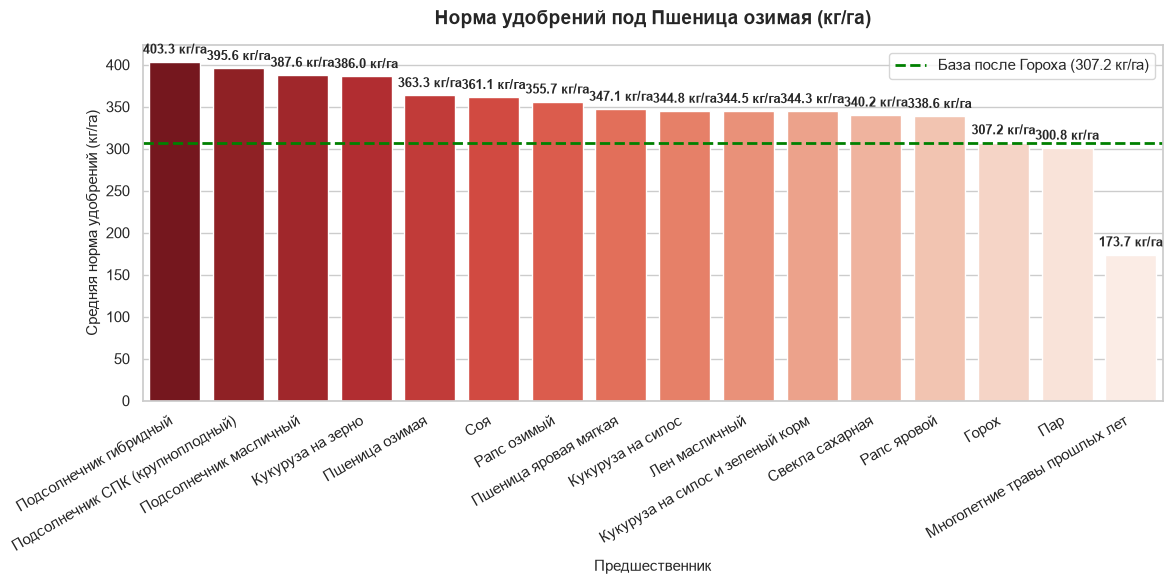

In [49]:
# Отбираем целевую культуру и только актуальные данные с зафиксированными удобрениями (> 0)
target_crop = "Пшеница озимая"
df_wheat_fert = df_merged_study[
    (df_merged_study["crop_name"] == target_crop)
    & (df_merged_study["fert_norma_ha"] > 0)
].copy()

# Расчет ключевых метрик по всем предшественникам с N >= 30
proof_table = (
    df_wheat_fert.groupby("prev_crop")
    .agg(
        count=("field_id", "count"),
        mean_fert=("fert_norma_ha", "mean"),
        median_fert=("fert_norma_ha", "median"),
        median_yield_ratio=("yield_ratio", "median"),
    )
    .query("count >= 30")
    .sort_values(by="mean_fert", ascending=False)
)

# Расчет % перерасхода относительно Гороха (можно и другую культуру)
if any(proof_table.index.str.contains("Горох", case=False, na=False)):
    peas_mean = proof_table[
        proof_table.index.str.contains("Горох", case=False, na=False)
    ]["mean_fert"].values[0]
    proof_table["перерасход_к_гороху_%"] = (
        (proof_table["mean_fert"] - peas_mean) / peas_mean * 100
    )

print(proof_table.round(2).to_string())

# Визуализация 
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=proof_table.reset_index(),
    x="prev_crop",
    y="mean_fert",
    hue="prev_crop",
    palette="Reds_r",
    legend=False,
)

if "peas_mean" in locals():
    plt.axhline(
        peas_mean,
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"База после Гороха ({peas_mean:.1f} кг/га)",
    )

plt.title(
    f"Норма удобрений под {target_crop} (кг/га)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Предшественник", fontsize=11)
plt.ylabel("Средняя норма удобрений (кг/га)", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="upper right")

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(
            f"{height:.1f} кг/га",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
            fontsize=9.5,
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

### Результаты

Все три группы подсолнечника заняли 1, 2 и 3 места по расходу удобрений – от 387.6 до 403.3 кг/га.

| Предшественник | Норма удобрений (кг/га) | Перерасход к гороху |
|----------------|-------------------------|----------------------|
| Подсолнечник гибридный | 403.3 | +31.3% |
| Подсолнечник СПК        | 390.2 | +27.0% |
| Подсолнечник масличный  | 387.6 | +26.2% |
| Пар              | 300.8 | -2.1% |


- Под пшеницу после подсолнечника вносят на 26.2% … +31.3% больше удобрений, чем после гороха (307.2 кг/га).
- Это также на 28.8% больше, чем после чистого пара (300.8 кг/га).

---

##### Вывод

Урожайность пшеницы после подсолнечника такая (на тех графиках) из-за большого кол-во удобрений.


#### Проверка пара после подсолнуха

In [80]:
YEAR_COL = "year"

# Сортируем данные по полю и хронологии
df_seq = df_merged.sort_values(by=["field_id", YEAR_COL]).copy()

# Определяем следующую культуру и следующий год для каждого поля
df_seq["next_crop"] = df_seq.groupby("field_id")["crop_name"].shift(-1)
df_seq["next_year"] = df_seq.groupby("field_id")[YEAR_COL].shift(-1)

# Фильтруем только последовательные года (без разрывов в истории)
df_seq["is_consecutive"] = (df_seq["next_year"] - df_seq[YEAR_COL]) == 1

# Выделяем все записи с подсолнечником, у которых есть известные данные на следующий год
sunflower_mask = df_seq["crop_name"].str.contains(
    "Подсолнечник", case=False, na=False
)
sunflower_seq = df_seq[
    sunflower_mask & df_seq["is_consecutive"] & df_seq["next_crop"].notna()
].copy()

# Считаем
total_sunflower = len(sunflower_seq)
fallow_cases = sunflower_seq["next_crop"].str.contains(
    "Пар", case=False, na=False
).sum()
pct_fallow = (fallow_cases / total_sunflower * 100) if total_sunflower > 0 else 0

print(f"Всего подходящих записей: {total_sunflower}")
print(f"Пар после подсолнуха: {fallow_cases} случаев")
print(f"Доля: {pct_fallow:.2f}%\n")

print("Культуры после подсолнуха:")
top_next = (
    sunflower_seq["next_crop"]
    .value_counts(normalize=True)
    .head(5)
    .mul(100)
    .round(2)
)
for crop, pct in top_next.items():
    print(f"  - {crop}: {pct}%")

Всего подходящих записей: 3401
Пар после подсолнуха: 104 случаев
Доля: 3.06%

Культуры после подсолнуха:
  - Пшеница озимая: 84.3%
  - Пшеница яровая мягкая: 7.35%
  - Пар: 3.06%
  - Ячмень яровой: 1.91%
  - Рис: 0.79%


#### Примеры

In [57]:
# Поиск и ранжирование полей по полноте истории и частоте подсолнечника
field_metrics = []

for field_id, group in df_merged_study.groupby("field_id"):
    history = group.sort_values("year")
    
    # Подсолнечник - Пшеница озимая
    has_target_sequence = False
    for i in range(len(history) - 1):
        curr_crop = str(history.iloc[i]["crop_name"])
        next_crop = str(history.iloc[i + 1]["crop_name"])
        if "Подсолнечник" in curr_crop and "Пшеница озимая" in next_crop:
            has_target_sequence = True
            break
            
    if has_target_sequence:
        # Считаем количество лет с непустой урожайностью (без NaN / Пар)
        active_years = history["productivity"].notna().sum()
        # Считаем количество лет, когда высевался подсолнечник
        sunflower_count = history["crop_name"].str.contains("Подсолнечник", case=False, na=False).sum()
        
        field_metrics.append({
            "field_id": field_id,
            "active_years": active_years,
            "sunflower_count": sunflower_count
        })

# Преобразуем в df и сортируем
df_ranked_fields = pd.DataFrame(field_metrics)
df_ranked_fields = df_ranked_fields.sort_values(
    by=["sunflower_count", "active_years"], 
    ascending=[False, False]
)

# Отбираем топ-3 самых информативных поля
examples = df_ranked_fields["field_id"].head(3).tolist()

print(f"Всего найдено полей: {len(df_ranked_fields)}")
print(f"Примеры:\n")

# вывод истории
for idx, field_id in enumerate(examples, 1):
    field_history = df_merged_study[
        df_merged_study["field_id"] == field_id
    ].sort_values("year").copy()

    field_name = field_history.iloc[0]["field_name"]
    division = field_history.iloc[0]["division"]

    print(f"#{idx}: {field_name} (ID: {field_id}) | Дивизион: {division}")

    history_df = pd.DataFrame()
    history_df["Год"] = field_history["year"].astype(int)
    history_df["Культура"] = field_history["crop_name"]
    history_df["Урожайность"] = field_history["productivity"].round(1)
    history_df["Yield Ratio"] = field_history["yield_ratio"].round(2)
    history_df["Удобрения (кг/га)"] = field_history.apply(
        lambda r: round(r["fert_norma_ha"], 1) if r.get("has_fertilizer") == 1 else 0.0, axis=1
    )

    display(history_df)
    print("\n")

# табл с примера
summary_data = []

for idx, field_id in enumerate(examples, 1):
    field_history = df_merged_study[
        df_merged_study["field_id"] == field_id
    ].sort_values("year")

    field_name = field_history.iloc[0]["field_name"]

    for i in range(len(field_history) - 1):
        current_crop = field_history.iloc[i]["crop_name"]
        next_row = field_history.iloc[i + 1]

        if "Подсолнечник" in str(current_crop):
            sunflower_year = int(field_history.iloc[i]["year"])
            next_year = int(next_row["year"])
            next_crop = next_row["crop_name"]
            next_yr = round(next_row["yield_ratio"], 2) if pd.notna(next_row["yield_ratio"]) else None
            next_fert = round(next_row["fert_norma_ha"], 1) if next_row.get("has_fertilizer") == 1 else 0.0

            summary_data.append({
                "Пример": f"#{idx}",
                "ID поля": field_id,
                "Название поля": field_name,
                "Год подсолнечника": sunflower_year,
                "Следующий год": next_year,
                "Следующая культура": next_crop,
                "Yield Ratio": next_yr,
                "Удобрения (кг/га)": next_fert
            })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

Всего найдено полей: 2296
Примеры:

#1: 61-12-ЧЕРН-005 (ID: 14621) | Дивизион: Дивизион Ростовский


,Год,Культура,Урожайность,Yield Ratio,Удобрения (кг/га)
7910,2016,Пшеница озимая,38.2,0.79,0.0
7911,2017,Подсолнечник масличный,21.4,0.90,0.0
7912,2018,Пшеница озимая,23.7,0.64,0.0
7913,2019,Подсолнечник масличный,21.0,0.87,0.0
7914,2020,Пшеница озимая,29.4,0.69,0.0
7915,2021,Подсолнечник масличный,24.6,1.02,0.0
7916,2022,Пшеница озимая,36.7,0.78,410.9
7917,2023,Подсолнечник масличный,21.1,0.86,0.0
7918,2024,Пшеница озимая,44.4,1.15,408.0
7919,2025,Подсолнечник масличный,3.0,0.45,0.0




#2: 61-12-ЧЕРН-006 (ID: 14711) | Дивизион: Дивизион Ростовский


,Год,Культура,Урожайность,Yield Ratio,Удобрения (кг/га)
8320,2016,Подсолнечник масличный,22.4,0.93,0.0
8321,2017,Пшеница озимая,49.8,0.93,0.0
8322,2018,Подсолнечник масличный,17.3,0.99,0.0
8323,2019,Пшеница озимая,46.1,1.15,0.0
8324,2020,Подсолнечник масличный,15.7,0.87,0.0
8325,2021,Пшеница озимая,43.2,0.92,343.0
8326,2022,Подсолнечник масличный,23.1,1.29,0.0
8327,2023,Пшеница озимая,41.5,0.86,281.8
8328,2024,Подсолнечник масличный,18.1,1.26,0.0
8329,2025,Пшеница озимая,27.6,1.28,281.8




#3: 61-06-ПОЗД-005 (ID: 14742) | Дивизион: Дивизион Ростовский


,Год,Культура,Урожайность,Yield Ratio,Удобрения (кг/га)
8410,2016,Лен масличный,12.8,1.09,0.0
8411,2017,Ячмень озимый,46.7,0.94,0.0
8412,2018,Подсолнечник масличный,16.2,0.92,0.0
8413,2019,Пшеница озимая,48.2,1.20,0.0
8414,2020,Подсолнечник масличный,12.4,0.69,0.0
8415,2021,Пшеница озимая,45.2,0.96,358.2
8416,2022,Подсолнечник масличный,17.5,0.98,0.0
8417,2023,Пшеница озимая,51.8,1.07,296.6
8418,2024,Подсолнечник масличный,18.9,1.32,0.0
8419,2025,Пшеница озимая,18.6,0.86,281.9


,Пример,ID поля,Название поля,Год подсолнечника,Следующий год,Следующая культура,Yield Ratio,Удобрения (кг/га)
0,#1,14621,61-12-ЧЕРН-005,2017,2018,Пшеница озимая,0.64,0.0
1,#1,14621,61-12-ЧЕРН-005,2019,2020,Пшеница озимая,0.69,0.0
2,#1,14621,61-12-ЧЕРН-005,2021,2022,Пшеница озимая,0.78,410.9
3,#1,14621,61-12-ЧЕРН-005,2023,2024,Пшеница озимая,1.15,408.0
4,#2,14711,61-12-ЧЕРН-006,2016,2017,Пшеница озимая,0.93,0.0
5,#2,14711,61-12-ЧЕРН-006,2018,2019,Пшеница озимая,1.15,0.0
6,#2,14711,61-12-ЧЕРН-006,2020,2021,Пшеница озимая,0.92,343.0
7,#2,14711,61-12-ЧЕРН-006,2022,2023,Пшеница озимая,0.86,281.8
8,#2,14711,61-12-ЧЕРН-006,2024,2025,Пшеница озимая,1.28,281.8
9,#3,14742,61-06-ПОЗД-005,2018,2019,Пшеница озимая,1.20,0.0


**Промежуточный вывод:**
    
- На данных полях идёт чередование «подсолнечник - пшеница" без исп. паров.

- неплохой индекс урожайности пшеницы достигается за счет большого кол-во норм удобрений - от 340 до 410 кг/га.

---

#### Сравнение с другой культурой

In [61]:
# беру тот же дивизион
target_division = df_merged_study[df_merged_study["field_id"] == examples[0]]["division"].iloc[0]

print(f"Сравниваем поля внутри одного дивизиона: {target_division}\n")

# поля с пшеницей после Гороха или Пара 
favorable_crops = ["Горох", "Пар"]

df_same_div = df_merged_study[
    (df_merged_study["division"] == target_division) & 
    (df_merged_study["crop_name"] == "Пшеница озимая") &
    (df_merged_study["fert_norma_ha"] > 0) &
    (df_merged_study["year"] >= 2021)
].copy()

df_fav_control = df_same_div[
    df_same_div["prev_crop"].str.contains("Горох|Пар", case=False, na=False)
]

if not df_fav_control.empty:
    control_field_id = df_fav_control.iloc[0]["field_id"]
    
    # Выводим историю 
    control_history = df_merged_study[
        df_merged_study["field_id"] == control_field_id
    ].sort_values("year").copy()

    control_name = control_history.iloc[0]["field_name"]

    print(f"Поле: {control_name} (ID: {control_field_id})")

    ctrl_df = pd.DataFrame()
    ctrl_df["Год"] = control_history["year"].astype(int)
    ctrl_df["Культура"] = control_history["crop_name"]
    ctrl_df["Урожайность"] = control_history["productivity"].round(1)
    ctrl_df["Yield Ratio"] = control_history["yield_ratio"].round(2)
    ctrl_df["Удобрения (кг/га)"] = control_history.apply(
        lambda r: round(r["fert_norma_ha"], 1) if r.get("has_fertilizer") == 1 else 0.0, axis=1
    )

    display(ctrl_df)
    print("\n")

    #  сводную таблицу сравнения 
    sf_row = df_merged_study[
        (df_merged_study["field_id"] == examples[0]) & 
        (df_merged_study["crop_name"] == "Пшеница озимая") &
        (df_merged_study["prev_crop"].str.contains("Подсолнечник", case=False, na=False)) &
        (df_merged_study["fert_norma_ha"] > 0)
    ].iloc[0]

    # Берем пшеницу после гороха/пара
    fav_row = df_fav_control.iloc[0]

    comp_df = pd.DataFrame([
        {
            "Предшественник": "Подсолнечник (Плохой)",
            "ID поля": sf_row["field_id"],
            "Название поля": sf_row["field_name"],
            "Год": int(sf_row["year"]),
            "Урожайность (ц/га)": round(sf_row["productivity"], 1),
            "Yield Ratio": round(sf_row["yield_ratio"], 2),
            "Удобрения (кг/га)": round(sf_row["fert_norma_ha"], 1)
        },
        {
            "Предшественник": f"{fav_row['prev_crop']} (Хороший)",
            "ID поля": fav_row["field_id"],
            "Название поля": fav_row["field_name"],
            "Год": int(fav_row["year"]),
            "Урожайность (ц/га)": round(fav_row["productivity"], 1),
            "Yield Ratio": round(fav_row["yield_ratio"], 2),
            "Удобрения (кг/га)": round(fav_row["fert_norma_ha"], 1)
        }
    ])

    print(f"Сравнение: {target_division}):")
    display(comp_df)

Сравниваем поля внутри одного дивизиона: Дивизион Ростовский

Поле: 61-06-ПОЗД-012 (ID: 14628)


,Год,Культура,Урожайность,Yield Ratio,Удобрения (кг/га)
7930,2016,Пшеница озимая,41.5,0.86,0.0
7931,2017,Нут,NaN,NaN,0.0
7932,2018,Пшеница озимая,47.2,1.27,0.0
7933,2019,Пшеница озимая,45.3,1.13,0.0
7934,2020,Горох,32.1,1.08,0.0
7935,2021,Пшеница озимая,46.0,0.98,255.7
7936,2022,Пшеница озимая,38.5,0.82,397.4
7937,2023,Горох,38.9,1.07,0.3
7938,2024,Пшеница озимая,25.1,0.65,241.5
7939,2025,Пшеница озимая,18.2,0.84,369.8




Сравнение: Дивизион Ростовский):


,Предшественник,ID поля,Название поля,Год,Урожайность (ц/га),Yield Ratio,Удобрения (кг/га)
0,Подсолнечник (Плохой),14621,61-12-ЧЕРН-005,2022,36.7,0.78,410.9
1,Горох (Хороший),14628,61-06-ПОЗД-012,2021,46.0,0.98,255.7


**Промежуточный вывод:**
    
- Горох благоприятный предшественниук, и из-за этого норма 240–255 кг/га.

- Подсолнечник или повторная пшеница увел. норму агрохимии до 370–410 кг/га.

---

#### Динамика норм удобрений по годам (подсолнечник)

**Отбираем все поля, где озимая пшеница высевалась после масличного подсолнечника. Для каждого года считаем среднее всех внесенных удобрений (avg_fert) и средний индекс урожайности (avg_yield_ratio).**


Год | Кол-во полей | Ср. норма удобрений | Ср. yield_ratio
------------------------------------------------------------
2017 |        287.0 |                 0.0 |             0.99
2018 |        360.0 |                 0.0 |             0.95
2019 |        272.0 |                44.5 |             1.00
2020 |        178.0 |                81.7 |             0.97
2021 |        234.0 |               236.5 |             0.98
2022 |        206.0 |               241.7 |             0.92
2023 |        251.0 |               245.5 |             0.94
2024 |        252.0 |               370.5 |             0.89
2025 |        382.0 |               351.2 |             0.92


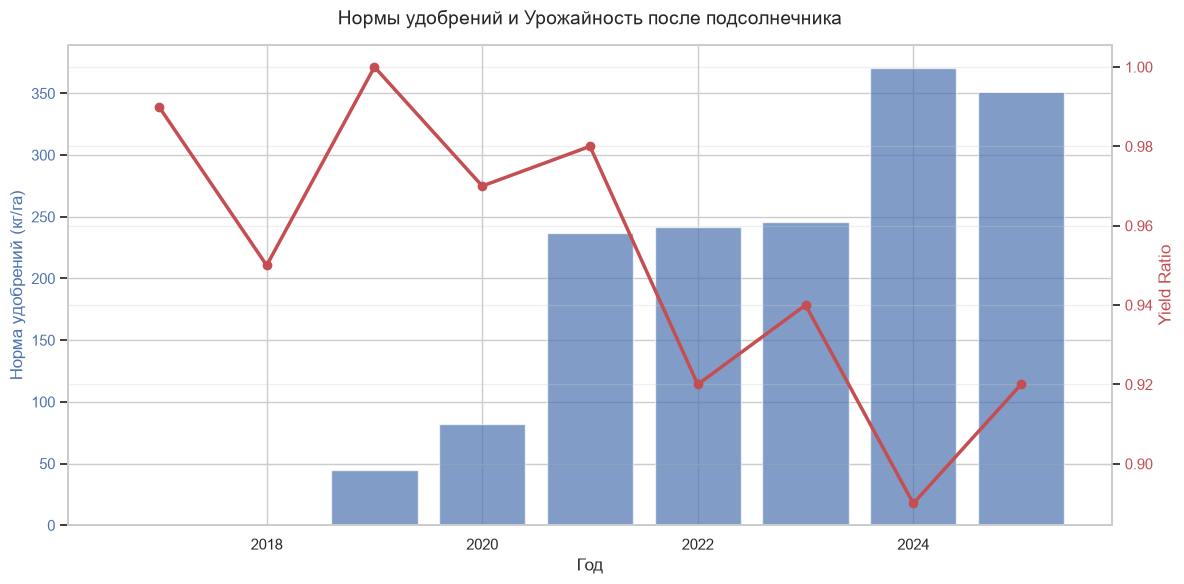

In [70]:
# Берем данные по подсолнечнику 
df_sunflower = df_merged_study[
    (df_merged_study["prev_crop"] == "Подсолнечник масличный") &
    (df_merged_study["crop_name"] == "Пшеница озимая")
].copy()

# Группируем по годам
yearly_stats = df_sunflower.groupby("year").agg(
    count=("field_id", "count"),
    avg_fert=("fert_norma_ha", "mean"),
    avg_yield_ratio=("yield_ratio", "mean")
).round(2)

print("\nГод | Кол-во полей | Ср. норма удобрений | Ср. yield_ratio")
print("-" * 60)
for year, row in yearly_stats.iterrows():
    print(f"{year} | {row['count']:>12} | {row['avg_fert']:>19.1f} | {row['avg_yield_ratio']:>16.2f}")

# Строим график
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(yearly_stats.index, yearly_stats["avg_fert"], color="#4C72B0", alpha=0.7, label="Норма удобрений (кг/га)")
ax1.set_xlabel("Год", fontsize=12)
ax1.set_ylabel("Норма удобрений (кг/га)", fontsize=12, color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")

ax2 = ax1.twinx()
ax2.plot(yearly_stats.index, yearly_stats["avg_yield_ratio"], marker="o", color="#C44E52", linewidth=2.5, label="Yield Ratio")
ax2.set_ylabel("Yield Ratio", fontsize=12, color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")

plt.title("Нормы удобрений и Урожайность после подсолнечника", fontsize=14, pad=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Промежуточный вывод:**

- Динамика за 2021–2025 гг. показывает, что наращивание объемов удобрений под пшеницу после подсолнечника (с 236 до 370 кг/га) не даёт рост урожайности. Индекс урожайности упал ниже нормы (с 0.98 до 0.89).

---

#### Структура удобрений по предшественникам

**Процент полей с озимой пшеницей, на которых применялся конкретный препарат при разном севообороте.**

In [66]:
target_crop = "Пшеница озимая"
predecessors = ["Подсолнечник масличный", "Горох", "Пар"]

df_chem_analysis = df_merged_study[
    (df_merged_study["crop_name"] == target_crop) & 
    (df_merged_study["prev_crop"].isin(predecessors)) &
    (df_merged_study["has_fertilizer"] == 1)
].copy()

structure_results = []

for pred in predecessors:
    pred_data = df_chem_analysis[df_chem_analysis["prev_crop"] == pred]
    total_fields = len(pred_data)
    
    field_ferts = []
    for fert_list in pred_data["fertilizers_list"]:
        if pd.notna(fert_list) and fert_list != "—":
            unique_ferts = set([f.strip() for f in fert_list.split(",")])
            field_ferts.extend(unique_ferts)
    
    fert_counts = Counter(field_ferts)
    
    for fert, count in fert_counts.most_common(5):
        pct = (count / total_fields) * 100
        structure_results.append({
            "Предшественник": pred,
            "Всего полей": total_fields,
            "Удобрение": fert,
            "Встречаемость": count,
            "Охват(%)": round(pct, 1)
        })

df_structure = pd.DataFrame(structure_results)
display(df_structure)

,Предшественник,Всего полей,Удобрение,Встречаемость,Охват(%)
0,Подсолнечник масличный,1116,Аммиачная селитра,1113,99.7
1,Подсолнечник масличный,1116,Аммофос,874,78.3
2,Подсолнечник масличный,1116,Гумат калия Сахалинский,807,72.3
3,Подсолнечник масличный,1116,Карбамид марки Б,524,47.0
4,Подсолнечник масличный,1116,Водорастворимое NPK удобрение 13:40:13 + МЭ,299,26.8
5,Горох,327,Аммиачная селитра,323,98.8
6,Горох,327,Аммофос,248,75.8
7,Горох,327,Гумат калия Сахалинский,241,73.7
8,Горох,327,Карбамид марки Б,144,44.0
9,Горох,327,Гумат калия Суфлер,73,22.3


**Промежуточный вывод:**
    
- Аммиачная селитра применяется в 99% полей и не зависит от предшественника.

- Различие в структуре это Аммофос. После подсолнечника и гороха его исп. до 78% полей, тогда как после пара - на 42% полей. Тоесть в препаратах сильных отличий нет, главное отличие в объёме.
---

#### Нормы удобрений по дивизионам

In [75]:
df_div_summary = (
    df_merged_study[
        (df_merged_study["crop_name"] == "Пшеница озимая") # целевая и смотрим для неё предшественника
        & (df_merged_study["prev_crop"].isin(predecessors))
        & (df_merged_study["fert_norma_ha"] > 0)
    ]
    .groupby(["division", "prev_crop"])["fert_norma_ha"]
    .agg(
        Количество_полей="count",
        Среднее_кг_га="mean",
        Медиана_кг_га="median",
    )
    .round(1)
    .reset_index()
    # Сначала группируем записи одного дивизиона, затем сортируем их от максимального среднего расхода к минимальному
    .sort_values(by=["division", "Среднее_кг_га"], ascending=[True, False])
)
display(df_div_summary)

,division,prev_crop,Количество_полей,Среднее_кг_га,Медиана_кг_га
1,"АО ""Краснояружская зерновая компания""",Подсолнечник масличный,16,200.6,200.1
0,"АО ""Краснояружская зерновая компания""",Пар,8,94.5,0.5
4,Дивизион Новокубанский,Подсолнечник масличный,52,405.1,441.3
3,Дивизион Новокубанский,Пар,182,253.4,196.6
2,Дивизион Новокубанский,Горох,3,188.9,200.4
6,Дивизион РИС,Подсолнечник масличный,24,449.0,450.6
5,Дивизион РИС,Пар,1,278.0,278.0
9,Дивизион Ростовский,Подсолнечник масличный,468,362.9,355.5
7,Дивизион Ростовский,Горох,161,318.0,261.3
8,Дивизион Ростовский,Пар,27,263.0,261.3


**Промежуточный вывод:**

- Пшеница после подсолнечника требует максимальных объемов удобрений во всех дивизионах.

---

### Дополненая карточка поля

In [96]:
def show_field_card(field_id):
  """Выводит полную историю поля Excel, статусом аномалий и объемами агрохимии"""
  field_id_str = str(field_id).strip()

  field_data = df_merged_study[
      df_merged_study["field_id"].astype(str) == field_id_str
  ].copy()

  if field_data.empty:
    print(f"Поле с id {field_id} не найдено в датасете.")
    return

  field_data = field_data.sort_values("year")
  info = field_data.iloc[0]

  # Извлечение метаданных из df_excel
  excel_meta_df = (
      df_excel[df_excel["ID поля"].astype(str) == field_id_str]
      if "df_excel" in globals()
      else pd.DataFrame()
  )

  if not excel_meta_df.empty:
    excel_meta = excel_meta_df.iloc[0]
    area = excel_meta.get("Площадь поля (га)", "н/д")
    yield_cat = excel_meta.get("Категория урожайности (Правила)", "н/д")
    stab_cat = excel_meta.get("Категория стабильности", "н/д")
  else:
    area = info.get("field_area", "н/д")
    yield_cat = info.get("yield_category", "н/д")
    stab_cat = info.get("stability_category", "н/д")

  field_name = info.get("field_name", f"Поле №{field_id}")
  division = info.get("division", "н/д")
  median_yr = info.get("median_yr", info.get("yield_ratio", 0))
  std_yr = info.get("std_yr", 0)

  # Шапка карточки метаданных
  print(f"Карточка поля: {field_name} (id: {field_id})")
  print(f"Дивизион: {division} | Площадь: {area} га")
  print(f"Статус в excel: {yield_cat} | {stab_cat}")
  print(
      f"Медианный индекс урожайности: {median_yr:.3f} | Разброс (std):"
      f" {std_yr:.3f}"
  )
  print("-" * 50)

  # Формирование основной таблицы с историей
  cols_map = {
      "year": "Год",
      "crop_name": "Культура",
      "prev_crop": "Предшественник",
      "productivity": "Урожайность (ц/га)",
      "yield_ratio": "Индекс урожайности",
      "dev_pct": "Отклонение (%)",
      "anomaly_type": "Тип отклонения",
  }

  existing_cols = [c for c in cols_map.keys() if c in field_data.columns]
  history = field_data[existing_cols].copy()

  # Формирование текстового статуса
  status_map = {
      "Отдых (Пар)": "отдых",
      "Нет данных": "нет данных",
      "Норма": "норма",
      "Провал (-)": "аномалия",
      "Всплеск (+)": "аномалия",
  }

  if "anomaly_type" in history.columns:
    history["Статус"] = history["anomaly_type"].map(status_map).fillna("—")

  # Добавление двух колонок по агрохимии
  history["Внесено удобрений (кг/га)"] = (
      field_data["fert_norma_ha"].fillna(0).round(1)
      if "fert_norma_ha" in field_data.columns
      else 0
  )

  if "szr_norma_ha" in field_data.columns:
    history["Внесено средств защиты"] = (
        field_data["szr_norma_ha"].fillna(0).round(1)
    )
  elif "szr_list" in field_data.columns:
    history["Внесено средств защиты"] = field_data["szr_list"].fillna("—")
  else:
    history["Внесено средств защиты"] = "—"

  history = history.rename(columns=cols_map)

  for col in ["Урожайность (ц/га)", "Отклонение (%)"]:
    if col in history.columns:
      history[col] = history[col].round(1)

  if "Индекс урожайности" in history.columns:
    history["Индекс урожайности"] = history["Индекс урожайности"].round(3)

  display(history.reset_index(drop=True))

  # Детализация аномалий
  if "is_anomaly" in field_data.columns:
    anomalies = field_data[field_data["is_anomaly"]]
    if len(anomalies) > 0:
      print(
          f"\nОбнаружено аномалий: {len(anomalies)} год(а) из {len(history)}."
      )
      for _, row in anomalies.iterrows():
        dev_val = row.get("dev_pct", 0)
        direction = "взлет" if dev_val > 0 else "провал"
        print(
            f"   - {int(row['year'])} ({row['crop_name']}): {direction}"
            f" ({dev_val:+.1f}%)"
        )
    else:
      print("\nАномалий не обнаружено.")

  # Суммарный объем хим нагрузки
  total_fert = history["Внесено удобрений (кг/га)"].sum()
  print("-" * 50)
  print(f" Всего удобрений: {total_fert:.1f} кг/га")




# Поиск примера и вызов карточки

df_fert_wheat = df_merged_study[
    (df_merged_study["crop_name"] == "Пшеница озимая")
    & (
        df_merged_study["prev_crop"].str.contains(
            "Подсолнечник", case=False, na=False
        )
    )
    & (df_merged_study["fert_norma_ha"] > 0)
].copy()

field_chem_summary = (
    df_fert_wheat.groupby("field_id")
    .agg(
        years_count=("year", "count"),
        years_list=("year", lambda x: sorted(list(x))),
        max_fert=("fert_norma_ha", "max"),
        avg_fert=("fert_norma_ha", "mean"),
    )
    .reset_index()
    .sort_values(by=["years_count", "max_fert"], ascending=[False, False])
)

print("Поля с наибольшей историей химии для примера:")
display(field_chem_summary.head(10))

if not field_chem_summary.empty:
  best_field_id = field_chem_summary.iloc[0]["field_id"]
  show_field_card(best_field_id)

Поля с наибольшей историей химии для примера:


,field_id,years_count,years_list,max_fert,avg_fert
228,14742,3,"[2021, 2023, 2025]",358.2010,312.238900
223,14711,3,"[2021, 2023, 2025]",343.0300,302.221200
648,20298,3,"[2021, 2023, 2025]",340.3000,280.082433
851,21500,2,"[2023, 2025]",755.0000,604.250000
874,21609,2,"[2022, 2024]",755.0000,671.900000
892,21705,2,"[2022, 2024]",755.0000,630.200000
895,21714,2,"[2021, 2024]",755.0000,659.150000
900,21762,2,"[2022, 2024]",755.0000,639.642000
891,21704,2,"[2022, 2024]",736.7552,556.077600
1192,27125,2,"[2020, 2025]",664.6020,463.251000


Карточка поля: 61-06-ПОЗД-005 (id: 14742)
Дивизион: Дивизион Ростовский | Площадь: 15.0 га
Статус в excel: Среднее | Стабильное
Медианный индекс урожайности: 0.969 | Разброс (std): 0.000
--------------------------------------------------


,Год,Культура,Предшественник,Урожайность (ц/га),Индекс урожайности,Отклонение (%),Тип отклонения,Статус,Внесено удобрений (кг/га),Внесено средств защиты
0,2016,Лен масличный,NaN,12.8,1.089,12.4,Норма,норма,0.0,—
1,2017,Ячмень озимый,Лен масличный,46.7,0.944,-2.6,Норма,норма,0.0,—
2,2018,Подсолнечник масличный,Ячмень озимый,16.2,0.921,-4.9,Норма,норма,0.0,—
3,2019,Пшеница озимая,Подсолнечник масличный,48.2,1.200,23.8,Норма,норма,0.0,—
4,2020,Подсолнечник масличный,Пшеница озимая,12.4,0.689,-28.9,Провал (-),аномалия,0.0,—
5,2021,Пшеница озимая,Подсолнечник масличный,45.2,0.961,-0.9,Норма,норма,358.2,—
6,2022,Подсолнечник масличный,Пшеница озимая,17.5,0.978,0.9,Норма,норма,0.0,—
7,2023,Пшеница озимая,Подсолнечник масличный,51.8,1.073,10.7,Норма,норма,296.6,—
8,2024,Подсолнечник масличный,Пшеница озимая,18.9,1.316,35.8,Всплеск (+),аномалия,0.0,—
9,2025,Пшеница озимая,Подсолнечник масличный,18.6,0.865,-10.8,Норма,норма,281.9,—



Обнаружено аномалий: 2 год(а) из 10.
   - 2020 (Подсолнечник масличный): провал (-28.9%)
   - 2024 (Подсолнечник масличный): взлет (+35.8%)
--------------------------------------------------
 Всего удобрений: 936.7 кг/га


---

### Дополнение химией графиков предшественников 

График сохранен: prev_crop_with_chem\median_prev_crop_chem.png


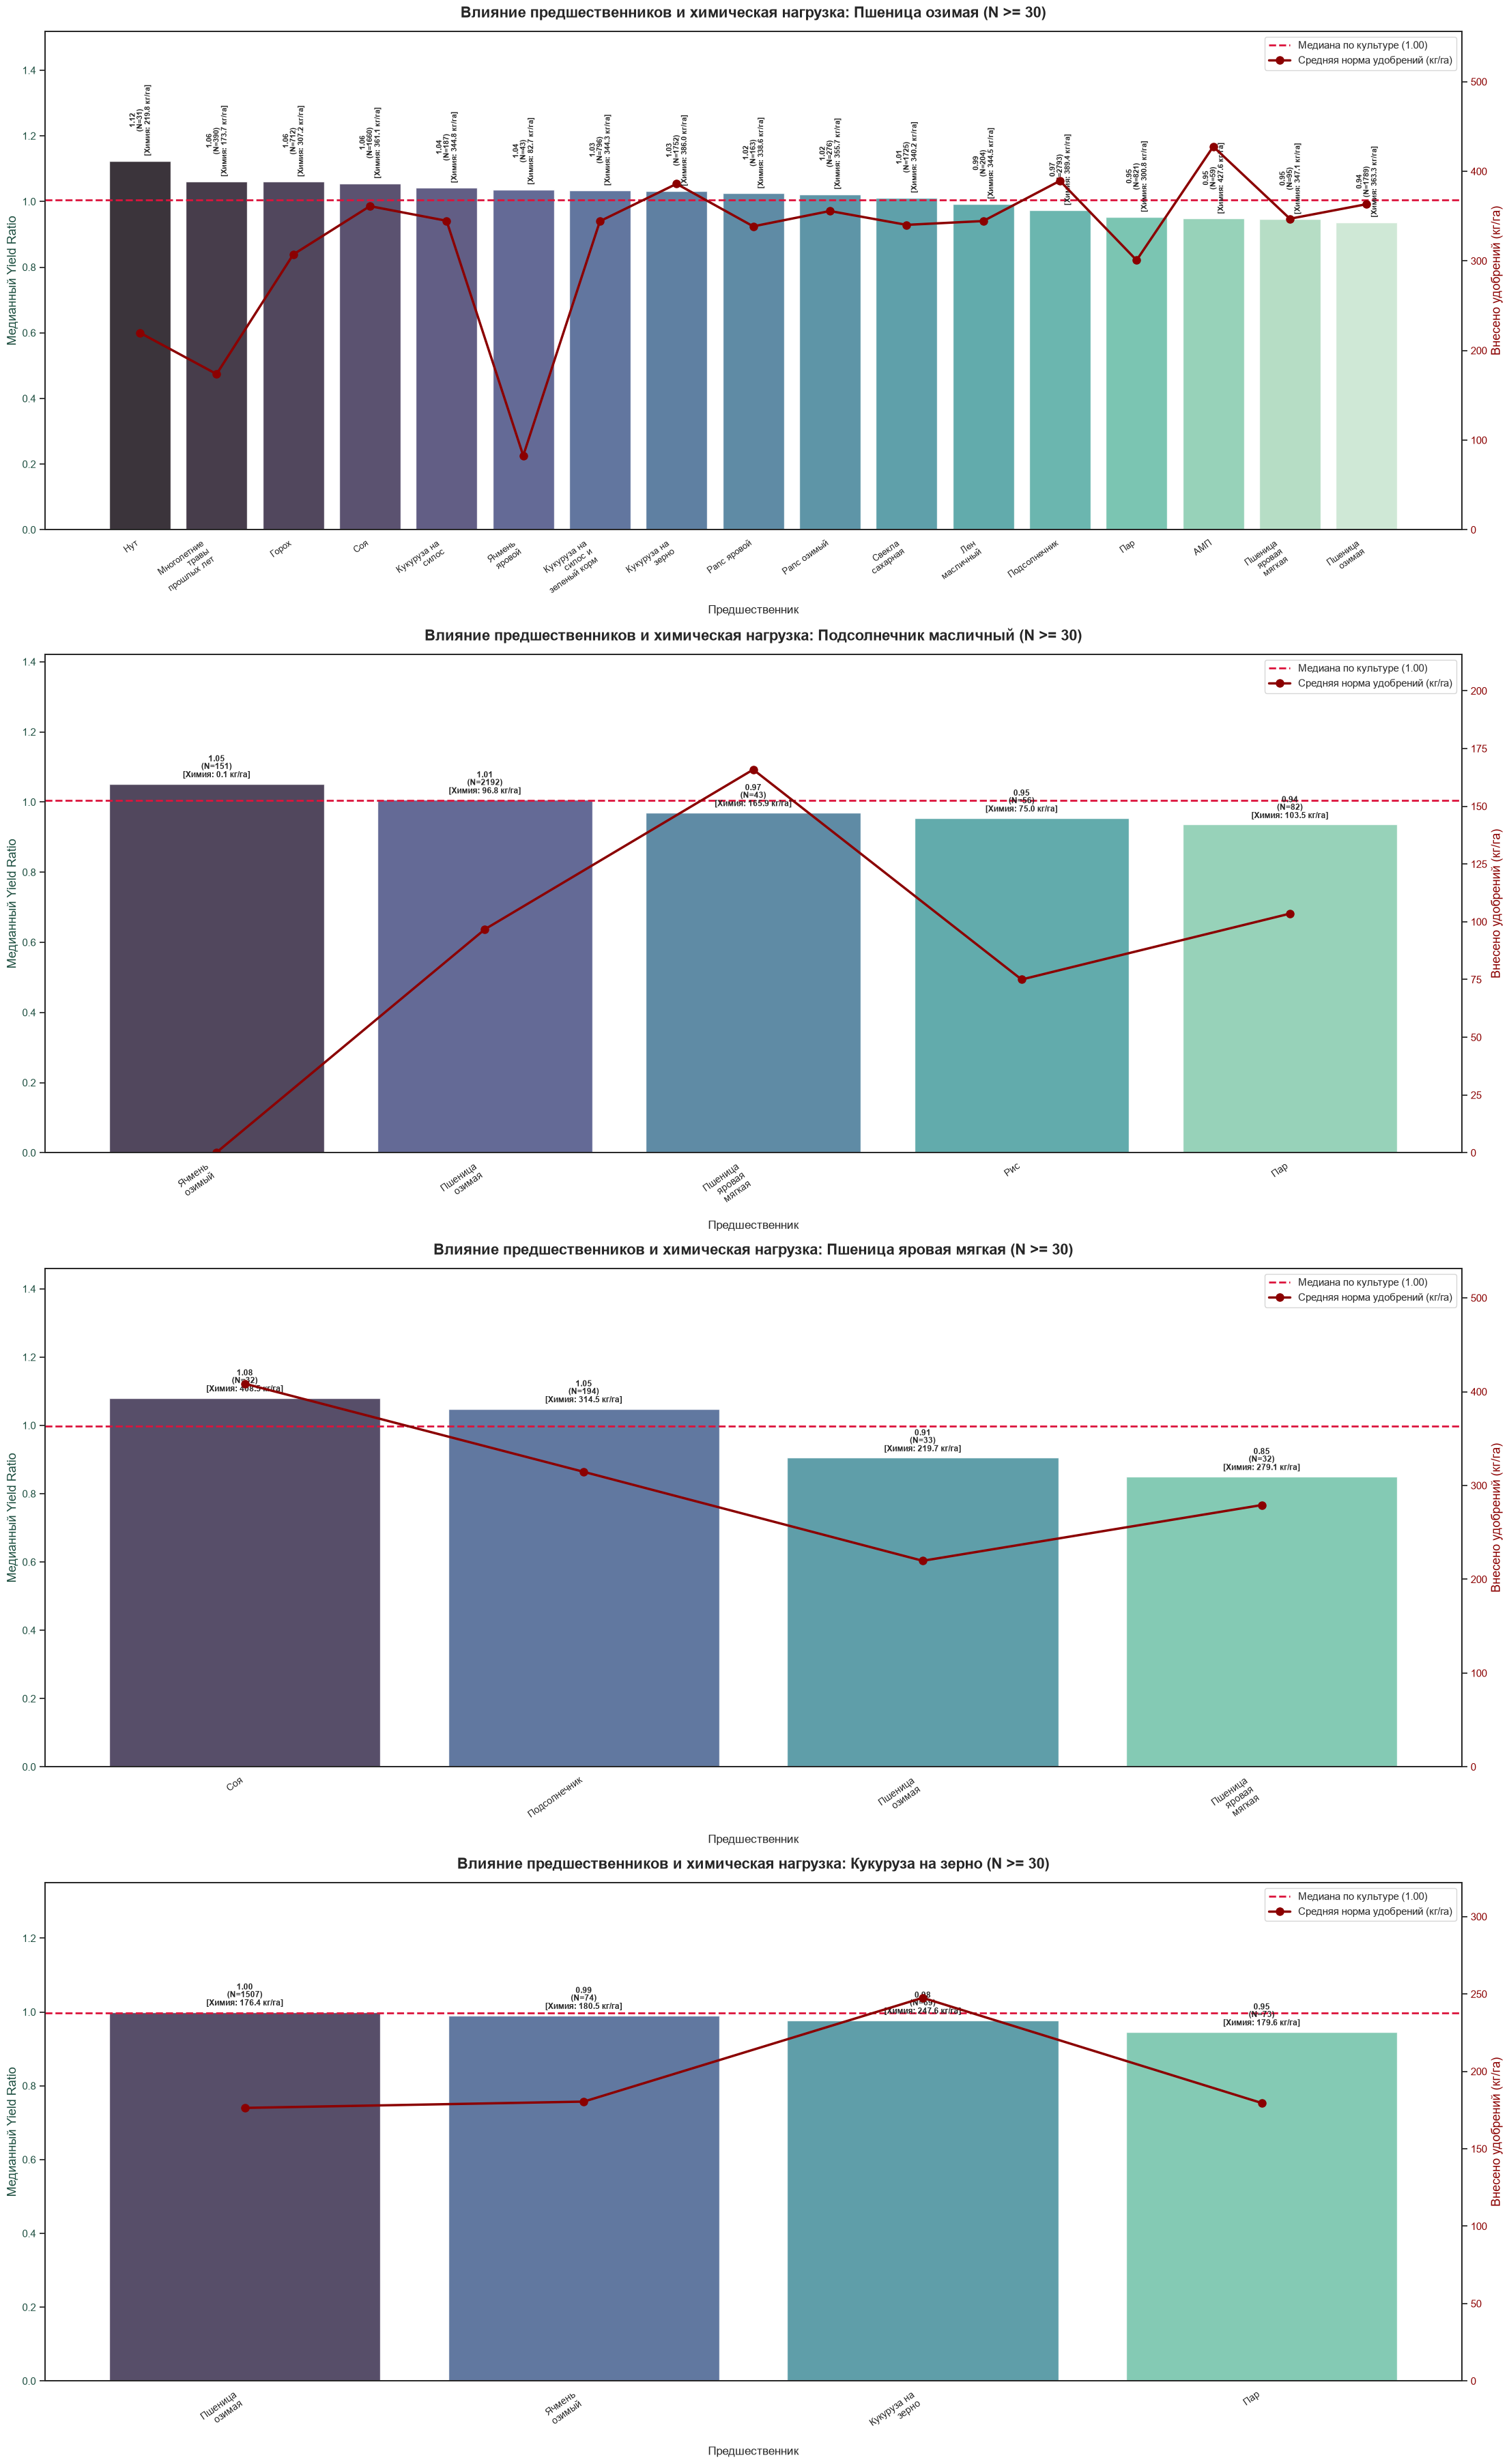

In [104]:
# Настройка
OUTPUT_DIR = "prev_crop_with_chem"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CROP_COL = "crop_name"
PREV_CROP_COL = "prev_crop"
YIELD_COL = "yield_ratio"
FERT_COL = "fert_norma_ha"

TARGET_CROPS = [
    "Пшеница озимая",
    "Подсолнечник масличный",
    "Пшеница яровая мягкая",
    "Кукуруза на зерно",
]
MIN_SAMPLES = 30

df_source = (
    df_merged_study if "df_merged_study" in globals() else df_merged.copy()
)

# Подготовка данных и очистка типов
df_work = df_source[df_source[CROP_COL].isin(TARGET_CROPS)].copy()

# соед всего подсолнуха
df_work[PREV_CROP_COL] = df_work[PREV_CROP_COL].apply(
    lambda x: (
        "Подсолнечник"
        if isinstance(x, str) and "подсолнечник" in x.lower()
        else x
    )
)

if FERT_COL in df_work.columns:
  df_work[FERT_COL] = pd.to_numeric(df_work[FERT_COL], errors="coerce").fillna(
      0
  )
else:
  df_work[FERT_COL] = 0.0

counts = df_work.groupby([CROP_COL, PREV_CROP_COL])[YIELD_COL].count()
valid_pairs = counts[counts >= MIN_SAMPLES].index

df_filtered = (
    df_work.set_index([CROP_COL, PREV_CROP_COL]).loc[valid_pairs].reset_index()
)

# Агрегация данных с расчетом химической нагрузки
pred_medians = (
    df_filtered.groupby([CROP_COL, PREV_CROP_COL])
    .agg(
        median=(YIELD_COL, "median"),
        count=(YIELD_COL, "count"),
        pct_above=(
            YIELD_COL,
            lambda x: (x.dropna() >= 1.00).mean() * 100
            if len(x.dropna()) > 0
            else 0,
        ),
        # Расчет средней химии ТОЛЬКО для полей с внесенными удобрениями (> 0)
        avg_fert=(
            FERT_COL,
            lambda x: x[x > 0].mean() if len(x[x > 0]) > 0 else 0,
),
    )
    .reset_index()
)

overall_medians = df_work.groupby(CROP_COL)[YIELD_COL].median().to_dict()

# -----------------------------------------------
# Построение графиков
sns.set_theme(style="white")

fig1, axes1 = plt.subplots(
    len(TARGET_CROPS),
    1,
    figsize=(22, 9 * len(TARGET_CROPS)),
    constrained_layout=True,
)

for idx, culture in enumerate(TARGET_CROPS):
  ax1 = axes1[idx] if len(TARGET_CROPS) > 1 else axes1
  sub_data = pred_medians[pred_medians[CROP_COL] == culture].sort_values(
      by="median", ascending=False
  )

  if sub_data.empty:
    ax1.set_title(
        f"Культура: {culture} (нет данных с N >= {MIN_SAMPLES})", fontsize=12
    )
    continue

  n_items = len(sub_data)
  is_dense = n_items > 10

  sub_data = sub_data.copy()
  sub_data["prev_crop_wrapped"] = sub_data[PREV_CROP_COL].apply(
      lambda x: textwrap.fill(str(x), width=12)
  )

  # Ось 1: Столбцы Yield Ratio
  sns.barplot(
      data=sub_data,
      x="prev_crop_wrapped",
      y="median",
      ax=ax1,
      palette="mako",
      hue="prev_crop_wrapped",
      legend=False,
      alpha=0.85,
  )

  # Линия общей медианы
  benchmark = overall_medians[culture]
  ax1.axhline(
      benchmark,
      color="crimson",
      linestyle="--",
      linewidth=2,
      label=f"Медиана по культуре ({benchmark:.2f})",
  )

  ax1.set_title(
      f"Влияние предшественников и химическая нагрузка: {culture} (N >="
      f" {MIN_SAMPLES})",
      fontsize=16,
      fontweight="bold",
      pad=15,
  )
  ax1.set_xlabel("Предшественник", fontsize=12, labelpad=10)
  ax1.set_ylabel("Медианный Yield Ratio", fontsize=13, color="#1b4d3e")
  ax1.tick_params(axis="y", labelcolor="#1b4d3e")
  plt.setp(
      ax1.get_xticklabels(),
      rotation=35,
      ha="right",
      fontsize=9 if is_dense else 10,
  )

  max_height = sub_data["median"].max()
  ax1.set_ylim(0, max_height * 1.35)

  # Ось 2: Динамика внесения удобрений
  ax2 = ax1.twinx()
  ax2.grid(False)

  ax2.plot(
      np.arange(len(sub_data)),
      sub_data["avg_fert"],
      color="darkred",
      marker="o",
      linewidth=2.5,
      markersize=8,
      label="Средняя норма удобрений (кг/га)",
  )

  ax2.set_ylabel("Внесено удобрений (кг/га)", fontsize=13, color="darkred")
  ax2.tick_params(axis="y", labelcolor="darkred")

  max_fert = sub_data["avg_fert"].max()
  ax2.set_ylim(0, max(max_fert * 1.3, 10))

  # Аннотации
  for i, (_, row) in enumerate(sub_data.iterrows()):
    height = row["median"]
    fert_val = row["avg_fert"]
    if not np.isnan(height):
      ax1.annotate(
          f"{height:.2f}\n(N={int(row['count'])})\n[Химия: {fert_val:.1f} кг/га]",
          xy=(i, height),
          xytext=(0, 5),
          textcoords="offset points",
          ha="center",
          va="bottom",
          fontsize=8 if is_dense else 8.5,
          fontweight="bold",
          rotation=90 if is_dense else 0,
          linespacing=1.1,
      )

  # Объединенная легенда
  lines1, labels1 = ax1.get_legend_handles_labels()
  lines2, labels2 = ax2.get_legend_handles_labels()
  ax1.legend(
      lines1 + lines2,
      labels1 + labels2,
      loc="upper right",
      frameon=True,
      fontsize=11,
  )

file_path_bar = os.path.join(OUTPUT_DIR, "median_prev_crop_chem.png")
fig1.savefig(file_path_bar, dpi=300, bbox_inches="tight")
print(f"График сохранен: {file_path_bar}")
plt.show()